In [93]:
!pip install numpy seaborn matplotlib pandas scikit-learn xgboost pycountry statsmodels requests

# TFM - Predictive analysis of suicide rates based on socioeconomic determinants and mental health prevalence

In [94]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import pycountry
import requests
import urllib3
import time
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Scikit-learn
from sklearn.preprocessing import RobustScaler
# Regression metrics — will be used in modelling section
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Models
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Configuration
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline
np.random.seed(42)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Preparing the base database
Mental illnesses prevalence extracted from the IHME website

In [95]:
# EU countries list since they are the ones of interest in this analysis
EU_countries_iso = [
    "DEU",
    "AUT",
    "BEL",
    "BGR",
    "CYP",
    "HRV",
    "DNK",
    "SVK",
    "SVN",
    "ESP",
    "EST",
    "FIN",
    "FRA",
    "GRC",
    "HUN",
    "IRL",
    "ITA",
    "LVA",
    "LTU",
    "LUX",
    "MLT",
    "NLD",
    "POL",
    "PRT",
    "CZE",
    "ROU",
    "SWE",
]

# Mapping dictionary based on the ISO alpha-3 codes for the EU
EU_regions = {
    "DEU": "Western Europe/Nordics",
    "FRA": "Western Europe/Nordics",
    "NLD": "Western Europe/Nordics",
    "BEL": "Western Europe/Nordics",
    "LUX": "Western Europe/Nordics",
    "AUT": "Western Europe/Nordics",
    "DNK": "Western Europe/Nordics",
    "FIN": "Western Europe/Nordics",
    "SWE": "Western Europe/Nordics",
    "IRL": "Western Europe/Nordics",
    "ESP": "Mediterranean",
    "ITA": "Mediterranean",
    "PRT": "Mediterranean",
    "GRC": "Mediterranean",
    "CYP": "Mediterranean",
    "MLT": "Mediterranean",
    "POL": "Eastern Europe",
    "CZE": "Eastern Europe",
    "SVK": "Eastern Europe",
    "HUN": "Eastern Europe",
    "ROU": "Eastern Europe",
    "BGR": "Eastern Europe",
    "SVN": "Eastern Europe",
    "HRV": "Eastern Europe",
    "EST": "Baltics",
    "LVA": "Baltics",
    "LTU": "Baltics",
}

social_economic_features = [
    "Suicide rate",  # Objective variable
    "GDP per capita",
    "Unemployment rate (%)",
    "Health expenditure (% GDP)",
    "Population",
    "Urban population (%)",
    "Physicians per 100000",
    "Gini index",
    "Internet users (% of population)",
]

health_related_features = [
    "Suicide rate",  # Objective variable
    "Alcohol use disorders",
    "Alzheimer's disease and other dementias",
    "Anxiety disorders",
    "Attention-deficit/hyperactivity disorder",
    "Autism spectrum disorders",
    "Bipolar disorder",
    "Conduct disorder",
    "Depressive disorders",
    "Schizophrenia",
    "Drug use disorders",
    # Eating disorders excluded — high VIF (12.3), dropped before modelling
]


ID_COLS = ["Country", "Code", "Year", "Region"]
TARGET = "Suicide rate"


# Function to obtain the ISO-Alpha 3 code of the country
def country_code(geo_name):
    """
    Looks up the ISO-Alpha 3 country code based on a given country text name.

    Parameters:
    -----------
    geo_name : str
        The textual name of the country (e.g., "Austria", "Greece").

    Returns:
    --------
    str or None
        The 3-letter ISO code if found (e.g., "AUT"), otherwise None.
    """
    try:
        pais = pycountry.countries.lookup(geo_name)
        return pais.alpha_3
    except LookupError:
        return None


# Function to graph the evolution of a suicide rate per country
def suicide_evolution_graph(dataframe, country_code, country_name):
    """
    Generates and displays a line plot showing the chronological evolution
    of the suicide rate for a specific country.

    Parameters:
    -----------
    dataframe : pd.DataFrame
        The consolidated master dataframe containing 'Code', 'Year', and 'Suicide rate'.
    country_code : str
        The 3-letter ISO code of the target country (e.g., "GRC").
    country_name : str
        The common name of the country to display in the plot title (e.g., "Greece").

    Returns:
    --------
    None
        Renders a matplotlib plot.
    """
    # Filtering dataframe for a specific country code
    df_country = dataframe[dataframe["Code"] == country_code].sort_values("Year")

    # Creating the figure and sizing it
    plt.figure(figsize=(12, 6))

    # Plotting the line with the values for the specified country
    plt.plot(
        df_country["Year"],
        df_country["Suicide rate"],
        color="#1f77b4",
        linestyle="-",
        marker="o",
        linewidth=2.5,
    )

    # Beauty personalization
    plt.title(
        f"Suicide rate evolution in {country_name}",
        fontsize=16,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Rate per 100,000 inhabitants", fontsize=12)

    # Showing every two years values in X axis
    min_year, max_year = int(df_country["Year"].min()), int(df_country["Year"].max())
    plt.xticks(range(min_year, max_year + 1, 2))

    # Adjusting margins and showing the graph
    plt.tight_layout()
    plt.show()

In [96]:
# ==============================================================================
# DATA PIPELINE STEP 1: IHME Mental Health Prevalence Base
# Database was filtered on gathering the data to only have EU countries
# ==============================================================================

# Base data from IHME
base_data = pd.read_csv("./data/IHME-GBD_2023_DATA-b62eec84-1.csv")
base_data["Code"] = base_data["location_name"].apply(country_code)
base_data_short = base_data[["location_name", "Code", "year", "cause_name", "val"]]
base_data_pivot = base_data_short.pivot(
    index=["location_name", "Code", "year"], columns="cause_name", values="val"
)
base_data_pivot.columns.name = None
base_data_pivot = base_data_pivot.reset_index()
df_base = base_data_pivot.rename(columns={"location_name": "Country", "year": "Year"})
df_base = df_base.drop(columns=["All causes"])
df = df_base[df_base["Year"] >= 2000].copy()
df

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia
6,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068
7,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193
8,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835
9,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007
10,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236
806,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357
807,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568
808,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098


## World Bank socioeconomic indicators
Indicators chosen:
- GDP per capita (USD). 
- Unemployment rate.
- Health expenditure per country (percentage of GDP).
- Population per country.
- Gini index. Measures the income inequalities. A greater unequality correlates to a greater psychosocial stress.
- Urban population (%). Allows to analyse if the urban environment (isolation, low resources) affects the rate.
- Physicians per 100,000 inhabitants. Measures the health system capability. The lower the rate, the lower the access to psychiatrists.
- Digital connectivity. Internet access could either be an issue for mental health or a network for support.

In [97]:
# ==============================================================================
# DATA PIPELINE STEP 2: Enhanced World Bank API Extraction
# ==============================================================================

# Defining the parameters in the URL of the API v2
INDICATORS = {
    "NY.GDP.PCAP.CD": "GDP per capita",
    "SL.UEM.TOTL.ZS": "Unemployment rate (%)",
    "SH.XPD.CHEX.GD.ZS": "Health expenditure (% GDP)",
    "SP.POP.TOTL": "Population",
    "SI.POV.GINI": "Gini index",
    "SP.URB.TOTL.IN.ZS": "Urban population (%)",
    "SH.MED.PHYS.ZS": "Physicians per 1000",
    "IT.NET.USER.ZS": "Internet users (% of population)",
}
REGION = "ALL"

df_features = df.copy()

for code, column_name in INDICATORS.items():
    url_wb = f"http://api.worldbank.org/v2/country/{REGION}/indicator/{code}?format=json&per_page=10000&date=2000:2026"

    # SSL certificate verification disabled for local network compatibility.
    # Remove verify=False if running in a production or public environment.
    response = requests.get(url_wb, verify=False)

    if response.status_code == 200:
        # World Bank returns a list where [0] is paging and [1] is the actual data
        raw_data = response.json()[1]

        # Converting to DataFrame
        df_wb = pd.DataFrame(raw_data)

        # It is a nested JSON, where country is a dictionary, which needs to be flattened:
        df_wb["Country"] = df_wb["country"].apply(lambda x: x["value"])
        df_wb["Code"] = df_wb["countryiso3code"].str.upper()
        df_wb["Year"] = df_wb["date"].astype(int)
        df_wb[column_name] = df_wb["value"]

        # Cleaning and ordering
        df_final_wb = df_wb[["Country", "Code", "Year", column_name]].dropna()

        df_final_eu = df_final_wb[df_final_wb["Code"].isin(EU_countries_iso)].copy()

        df_features = pd.merge(
            df_features,
            df_final_eu[["Code", "Year", column_name]],
            on=["Code", "Year"],
            how="left",
        )

        print(
            f"DataFrame '{column_name}' successfully created. Rows retrieved: {len(df_final_eu)}."
        )
        print("-" * 50)

if "Physicians per 1000" in df_features.columns:
    df_features["Physicians per 100000"] = df_features["Physicians per 1000"] * 100
    df_features.drop(columns=["Physicians per 1000"], inplace=True)

df_features

DataFrame 'GDP per capita' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Unemployment rate (%)' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Health expenditure (% GDP)' successfully created. Rows retrieved: 663.
--------------------------------------------------
DataFrame 'Population' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Gini index' successfully created. Rows retrieved: 589.
--------------------------------------------------
DataFrame 'Urban population (%)' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Physicians per 1000' successfully created. Rows retrieved: 616.
--------------------------------------------------
DataFrame 'Internet users (% of population)' successfully created. Rows retrieved: 678.
-------------------------------------------

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236,51648.989282,6.833,10.934443,10278887.0,29.3,87.708842,94.493443,428.8
644,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357,52568.572698,8.291,11.424587,10353442.0,28.9,87.942405,94.539431,432.2
645,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568,60647.541637,8.803,11.230136,10415811.0,29.8,88.174165,94.670316,440.8
646,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098,54836.890724,7.417,10.855057,10486941.0,31.6,88.403858,95.009703,NaN


## Preparing the WHO database for the join with the master database (predictive variable: suicide rate)

In [98]:
# ==============================================================================
# DATA PIPELINE STEP 3: WHO API Suicide Rates Join
# ==============================================================================

# Official indicator from the WHO for the mortality rate due to self-harm
INDICATOR = "SDGSUICIDE"
url = f"https://ghoapi.azureedge.net/api/{INDICATOR}"

print("Downloading dataset from the WHO API.")
response = requests.get(url, verify=False)

if response.status_code == 200:
    data = response.json()["value"]

    # Testing if the response returned any value.
    if len(data) == 0:
        print("The API responded but did not find any data for this indicator.")
    else:
        df_raw = pd.DataFrame(data)

        # Filtering to only keep BTSX (both sexes) and YEARSALL (all year groups).
        df_filtered = df_raw[
            (df_raw["Dim1"] == "SEX_BTSX") & (df_raw["Dim2"] == "AGEGROUP_YEARSALL")
        ].copy()

        # Selecting the columns of interest
        interest_columns = ["SpatialDim", "TimeDim", "NumericValue"]
        df_clean = df_filtered[interest_columns].copy()

        # Renaming to match the rest of the datasets
        df_clean.columns = ["Code", "Year", "Suicide rate"]

        # Sort chronologically by country and year
        df_clean = df_clean.sort_values(by=["Code", "Year"])

else:
    print(f"Error trying to connect with the API. Status code: {response.status_code}")

df_complete = pd.merge(
    df_features,
    df_clean[["Code", "Year", "Suicide rate"]],
    on=["Code", "Year"],
    how="left",
)

# Sort by country and year to ensure correct chronological ordering
# before interpolation and downstream groupby operations
df_complete = df_complete.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Separate the data set between the real world (not-known suicide rates) and the rest of the data
df_development = df_complete[df_complete["Year"] <= 2021].copy()
# Retain df_real_world for reference only — WHO data for 2022-2023 is unavailable
# so this dataset has no suicide rate labels and is not used in modelling.
df_real_world = df_complete[df_complete["Year"] >= 2022].copy()

display(df_development.head())

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2,17.383069


In [99]:
# ==============================================================================
# 1. DESCRIPTIVE STATISTICS
# ==============================================================================
print("Master Dataset Summary Statistics")
display(df_development.describe().T)

print("\nMissing values")
print(df_development.isnull().sum())

Master Dataset Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Year,594.0,2.010500e+03,6.349636e+00,2000.000000,2.005000e+03,2.010500e+03,2.016000e+03,2.021000e+03
Alcohol use disorders,594.0,2.640863e+03,6.501545e+02,1468.353858,2.154470e+03,2.638039e+03,3.166213e+03,3.930876e+03
Alzheimer's disease and other dementias,594.0,1.162906e+03,3.505339e+02,615.594485,9.072604e+02,1.109865e+03,1.317172e+03,2.490327e+03
Anxiety disorders,594.0,5.060044e+03,1.514067e+03,2850.328655,3.934236e+03,4.670571e+03,5.770123e+03,1.142191e+04
Attention-deficit/hyperactivity disorder,594.0,7.675910e+02,3.598561e+02,248.480691,4.405874e+02,7.954818e+02,9.792250e+02,1.722195e+03
Autism spectrum disorders,594.0,6.979302e+02,1.188224e+02,497.467873,5.765145e+02,7.303758e+02,7.675203e+02,1.011089e+03
Bipolar disorder,594.0,6.507963e+02,8.939936e+01,488.696921,5.619674e+02,6.689073e+02,7.169895e+02,8.472123e+02
Conduct disorder,594.0,3.712084e+02,5.047307e+01,281.621053,3.309906e+02,3.666408e+02,4.003332e+02,5.418604e+02
Depressive disorders,594.0,3.332831e+03,7.327951e+02,2229.578134,2.753071e+03,3.272819e+03,3.777113e+03,6.698489e+03
Drug use disorders,594.0,8.564169e+02,2.555415e+02,282.936650,6.690521e+02,8.318342e+02,9.782403e+02,1.852197e+03



Missing values
Country                                      0
Code                                         0
Year                                         0
Alcohol use disorders                        0
Alzheimer's disease and other dementias      0
Anxiety disorders                            0
Attention-deficit/hyperactivity disorder     0
Autism spectrum disorders                    0
Bipolar disorder                             0
Conduct disorder                             0
Depressive disorders                         0
Drug use disorders                           0
Eating disorders                             0
Schizophrenia                                0
GDP per capita                               0
Unemployment rate (%)                        0
Health expenditure (% GDP)                   0
Population                                   0
Gini index                                  54
Urban population (%)                         0
Internet users (% of population)            

## Inspecting missing values: Gini index and Physicians per 100,000
To have a clear idea of which value imputation method to use

In [100]:
print(
    df_development[
        df_development["Gini index"].isna()
        | df_development["Physicians per 100000"].isna()
    ]
)

         Country Code  Year  Alcohol use disorders  Alzheimer's disease and other dementias  Anxiety disorders  Attention-deficit/hyperactivity disorder  Autism spectrum disorders  Bipolar disorder  Conduct disorder  Depressive disorders  Drug use disorders  Eating disorders  Schizophrenia  GDP per capita  Unemployment rate (%)  Health expenditure (% GDP)  Population  Gini index  Urban population (%)  Internet users (% of population)  Physicians per 100000  Suicide rate
1        Austria  AUT  2001            3193.762279                              1143.969355        4046.938653                               1173.433463                 723.015405        719.736433        394.027233           2414.230764          875.548127        479.489990     342.045193    24430.495983                  4.007                    9.452435   8042293.0         NaN             66.840816                         39.185450                  398.9     18.508048
2        Austria  AUT  2002            3196.670699

## Missing values imputation
Linear interpolation chosen since there are consecutive years missing.

In [101]:
# Define the columns with missing values
features_with_NaN = ["Gini index", "Physicians per 100000"]

for col in features_with_NaN:
    # Linear interpolation within each country (only fills between known points)
    df_development[col] = df_development.groupby("Country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print("Remaining NaNs after interpolation:")
print(df_development[features_with_NaN].isnull().sum())

display(df_development.head())
print(df_development.isnull().sum())

Remaining NaNs after interpolation:
Gini index               0
Physicians per 100000    0
dtype: int64


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.280000,423.2,17.383069


Country                                     0
Code                                        0
Year                                        0
Alcohol use disorders                       0
Alzheimer's disease and other dementias     0
Anxiety disorders                           0
Attention-deficit/hyperactivity disorder    0
Autism spectrum disorders                   0
Bipolar disorder                            0
Conduct disorder                            0
Depressive disorders                        0
Drug use disorders                          0
Eating disorders                            0
Schizophrenia                               0
GDP per capita                              0
Unemployment rate (%)                       0
Health expenditure (% GDP)                  0
Population                                  0
Gini index                                  0
Urban population (%)                        0
Internet users (% of population)            0
Physicians per 100000             

## Suicide rate evolution — country spotlights
The following plots highlight the two extremes of the EU distribution and a mid-range reference country, contextualising the outliers identified later.

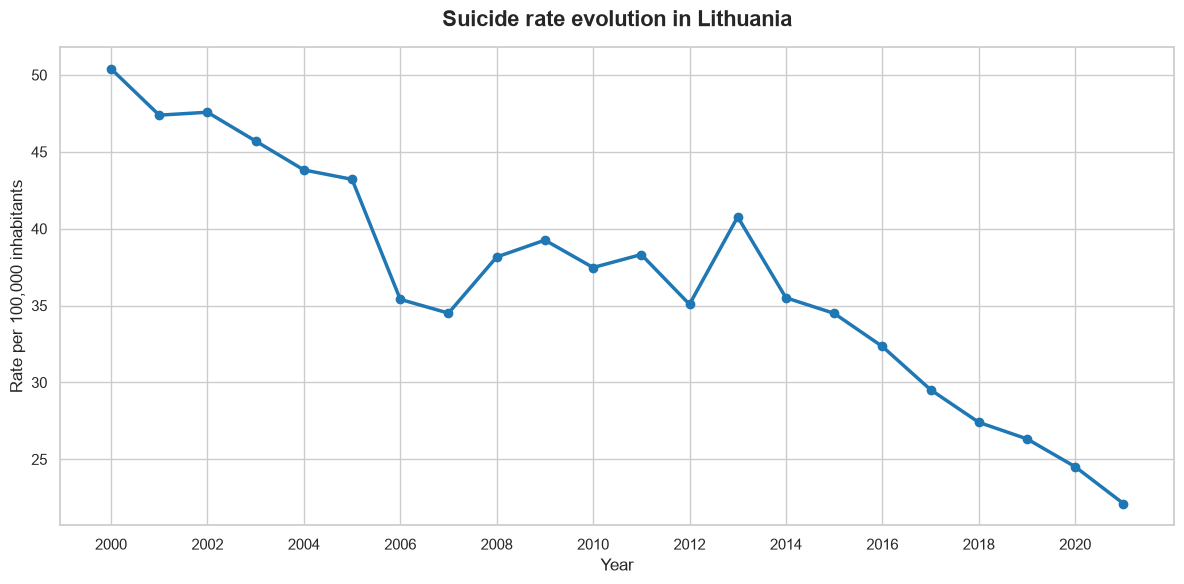

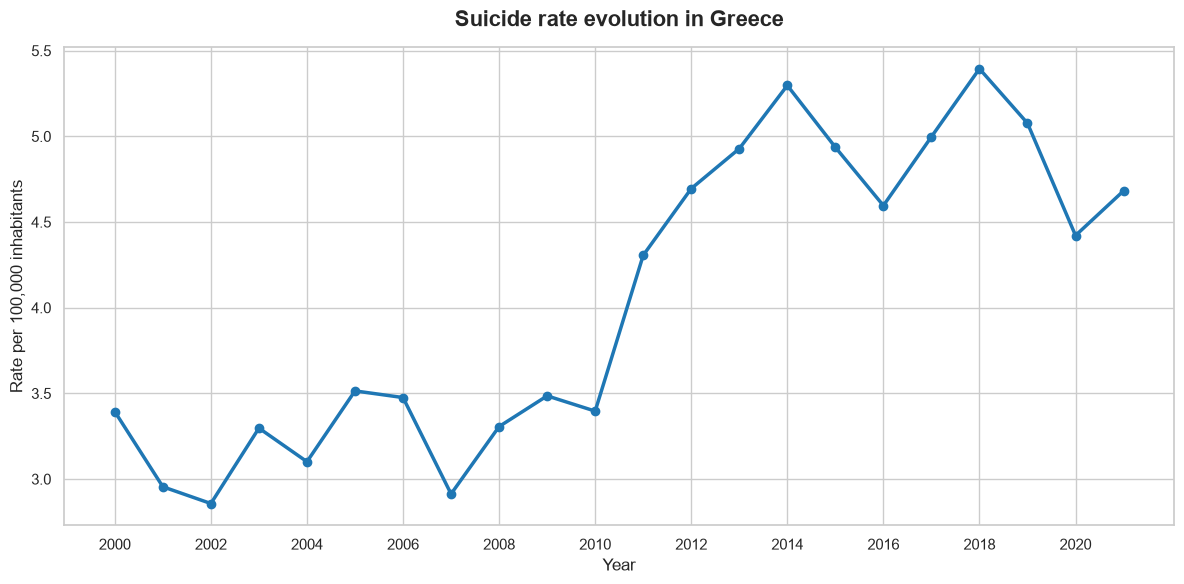

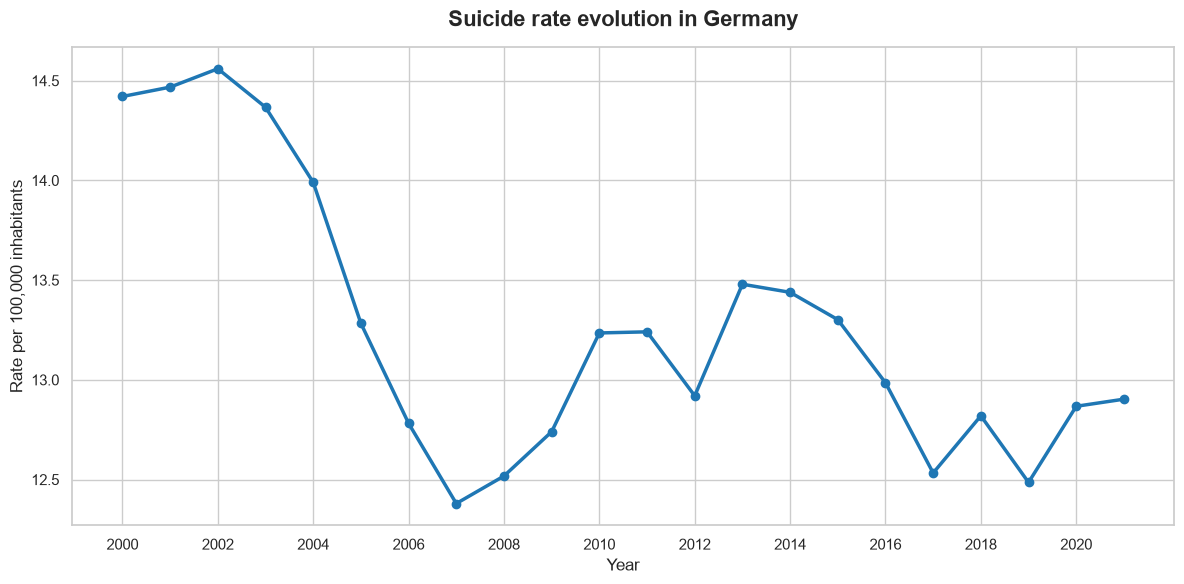

In [102]:
# Highest average suicide rate in the EU
suicide_evolution_graph(df_development, "LTU", "Lithuania")

# Lowest average suicide rate in the EU
suicide_evolution_graph(df_development, "GRC", "Greece")

# A mid-range country for reference
suicide_evolution_graph(df_development, "DEU", "Germany")

## Suicide rate trends by EU region (2000–2021)

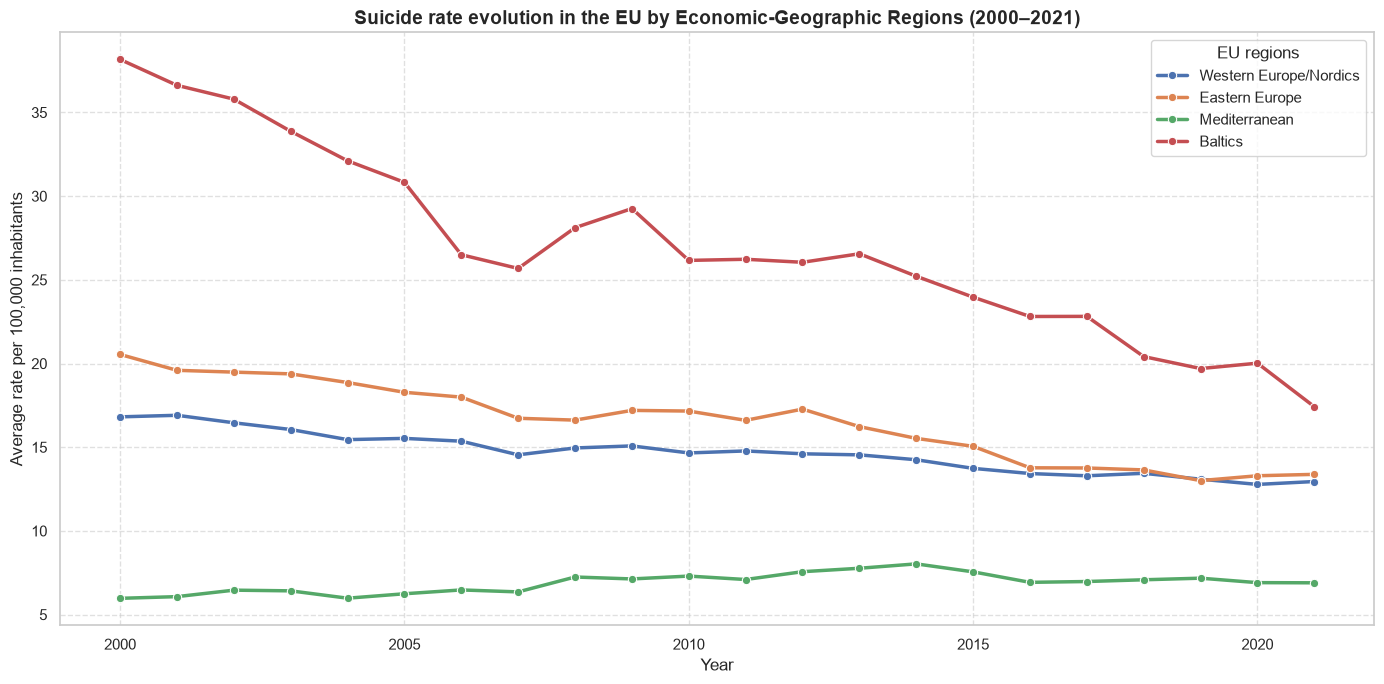

In [103]:
df_development["Region"] = df_development["Code"].map(EU_regions)

# Graphing the time evolution per region
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_development,
    x="Year",
    y="Suicide rate",
    hue="Region",
    marker="o",
    linewidth=2.5,
    errorbar=None,
)

plt.title(
    "Suicide rate evolution in the EU by Economic-Geographic Regions (2000–2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year")
plt.ylabel("Average rate per 100,000 inhabitants")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="EU regions")
plt.tight_layout()
plt.show()

## Cross-country distribution analysis

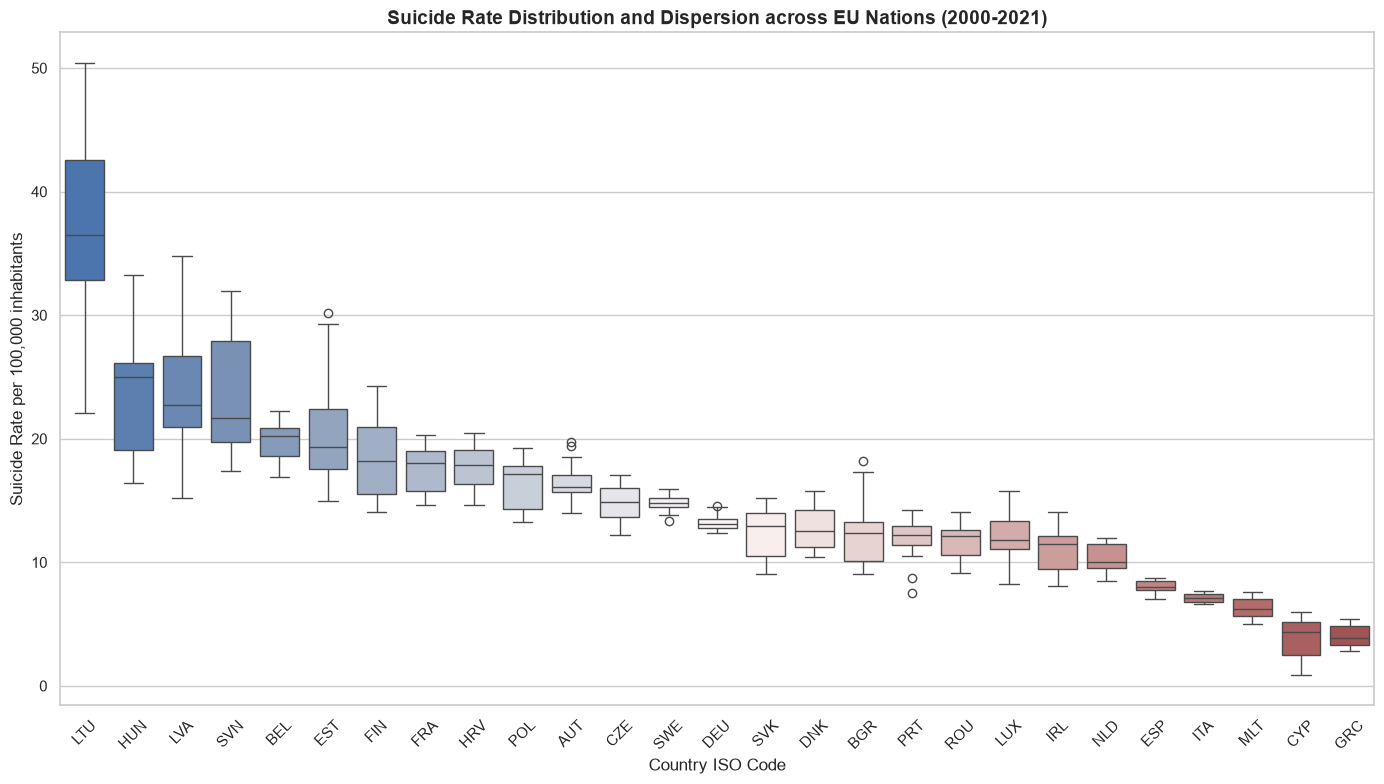

In [104]:
# ==============================================================================
# CROSS-COUNTRY DISTRIBUTION ANALYSIS
# ==============================================================================
# Distribution of Suicide Rates across different EU nations
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    palette="vlag",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
)
plt.title(
    "Suicide Rate Distribution and Dispersion across EU Nations (2000-2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Country ISO Code")
plt.ylabel("Suicide Rate per 100,000 inhabitants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature distribution analysis

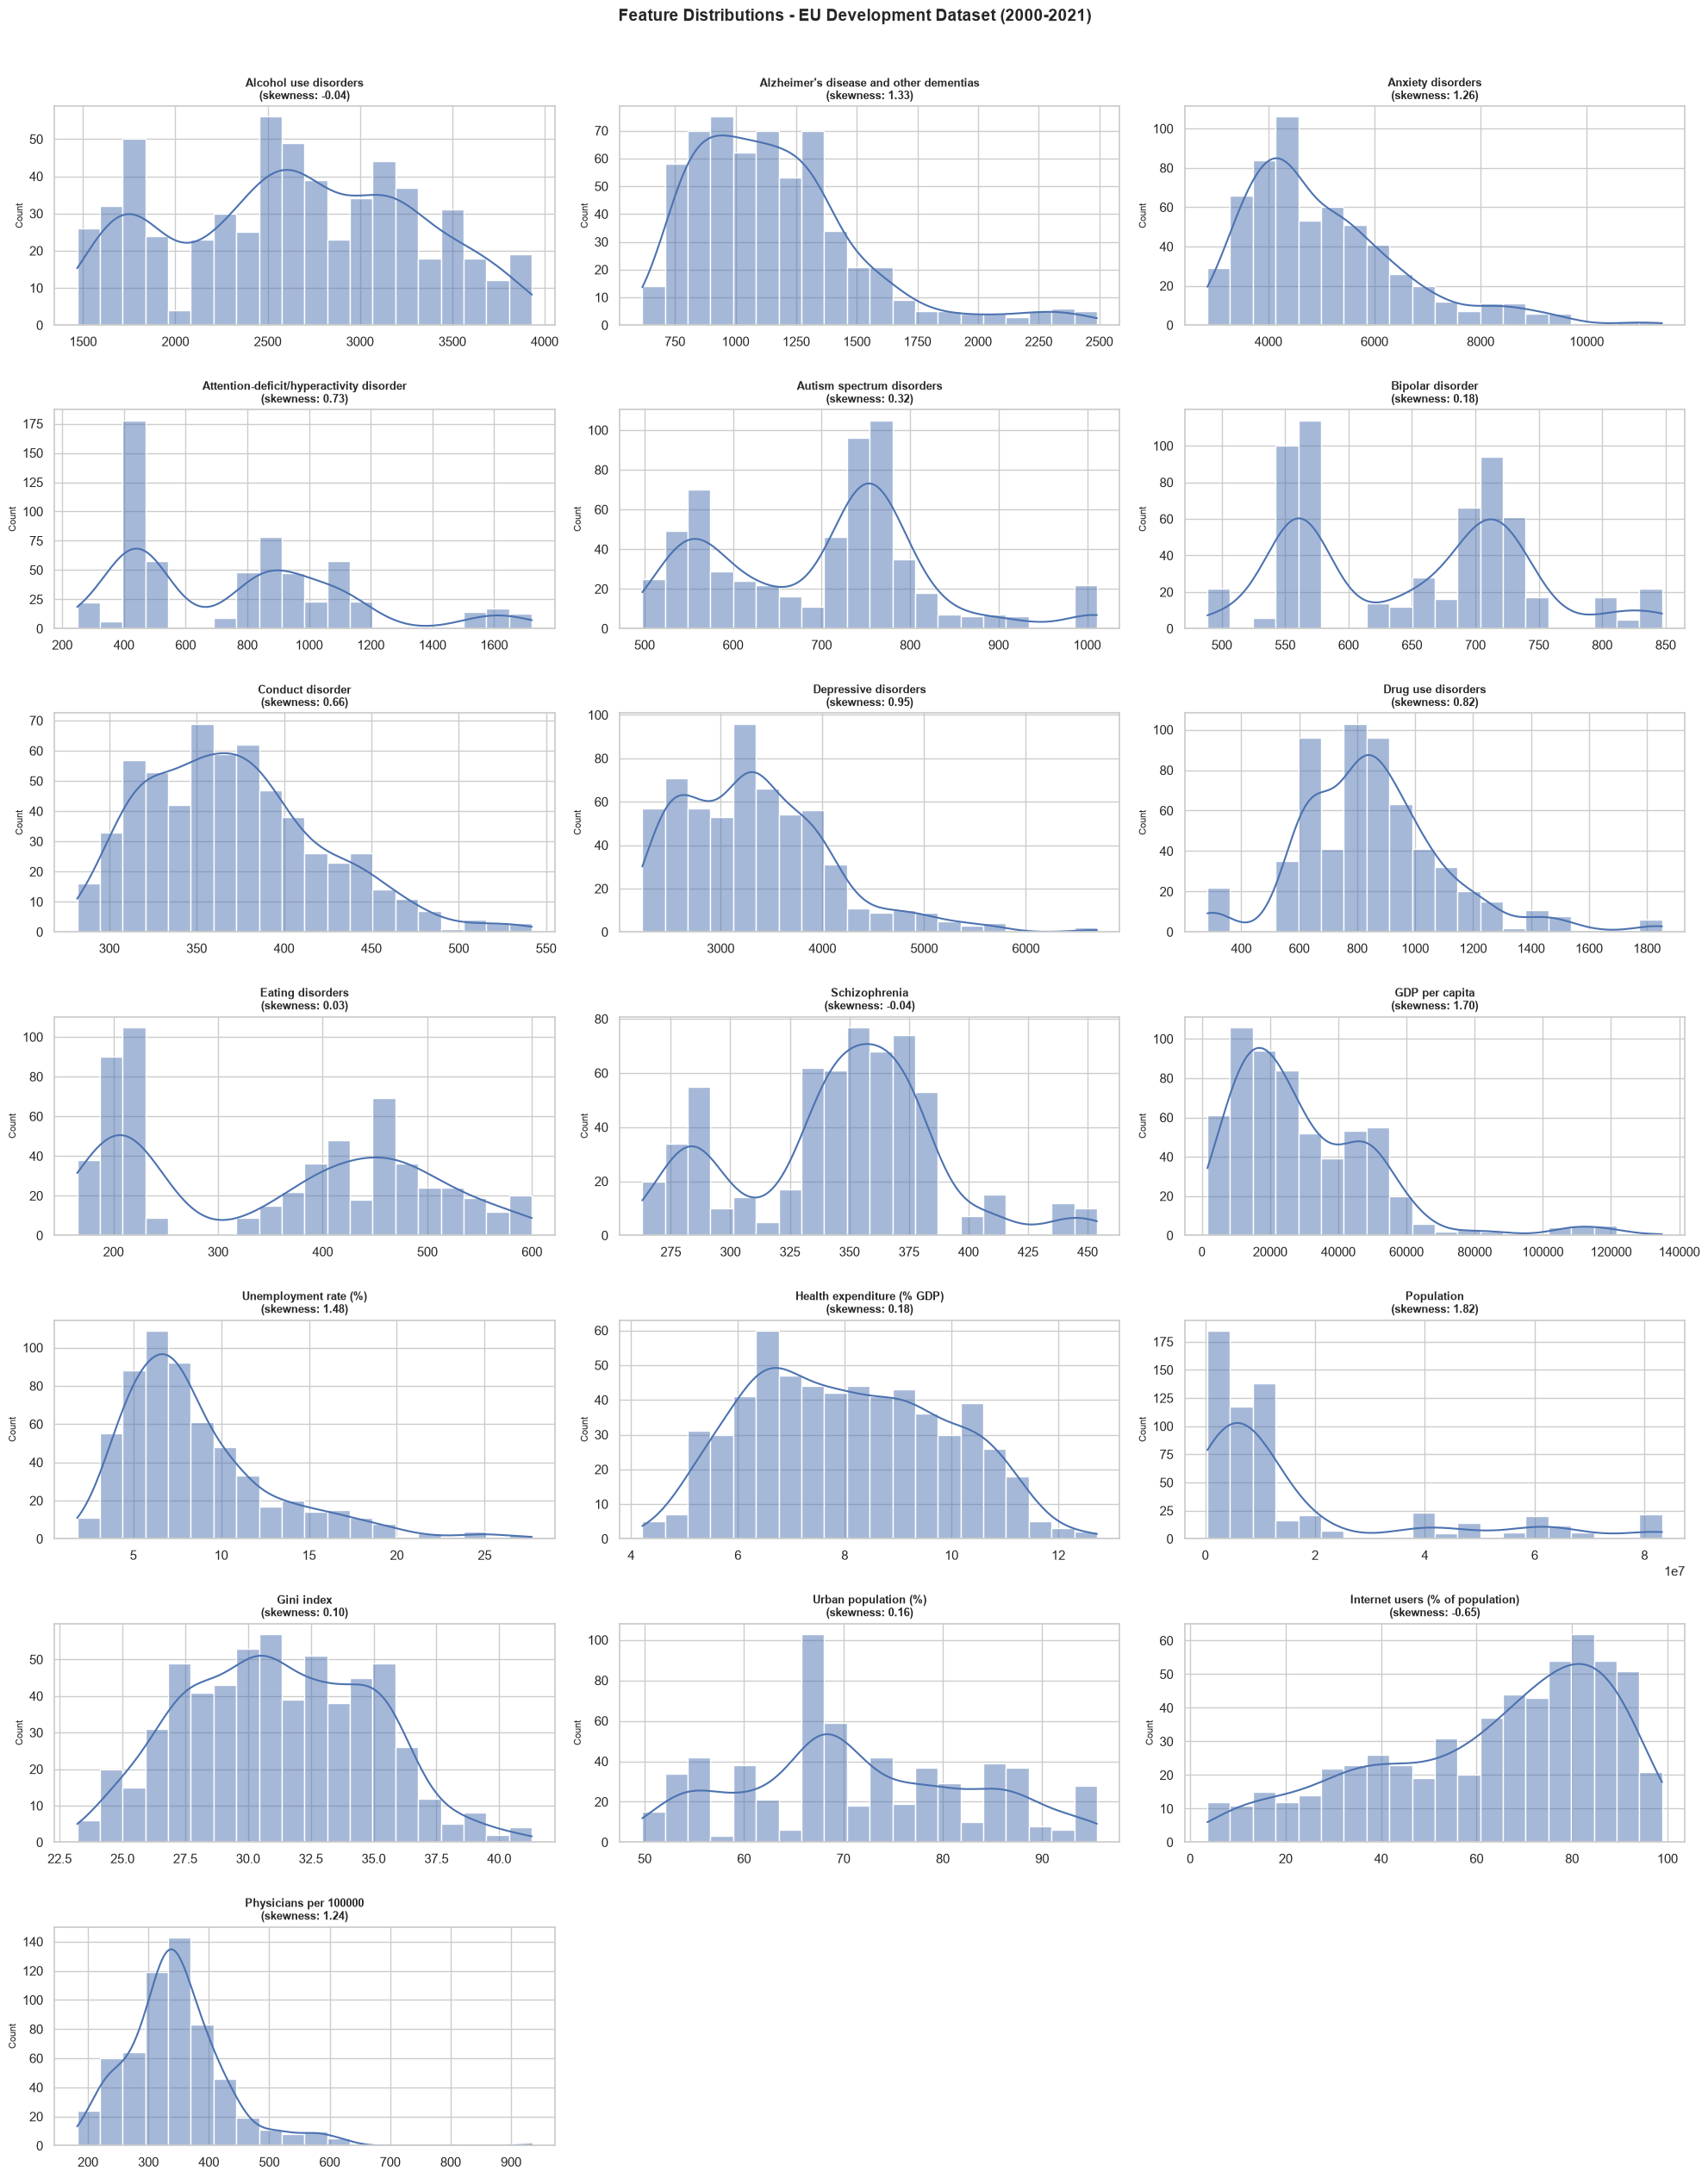


Skewness summary:
Population                                  1.82
GDP per capita                              1.70
Unemployment rate (%)                       1.48
Alzheimer's disease and other dementias     1.33
Anxiety disorders                           1.26
Physicians per 100000                       1.24
Depressive disorders                        0.95
Drug use disorders                          0.82
Attention-deficit/hyperactivity disorder    0.73
Conduct disorder                            0.66
Autism spectrum disorders                   0.32
Health expenditure (% GDP)                  0.18
Bipolar disorder                            0.18
Urban population (%)                        0.16
Gini index                                  0.10
Eating disorders                            0.03
Alcohol use disorders                      -0.04
Schizophrenia                              -0.04
Internet users (% of population)           -0.65
dtype: float64


In [105]:
# ==============================================================================
# FEATURE DISTRIBUTION ANALYSIS
# Histograms + KDE for all numerical features to identify skewness
# ==============================================================================

predictor_features = [c for c in df_development.columns if c not in ID_COLS + [TARGET]]

ncols = 3
nrows = (len(predictor_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(predictor_features):
    ax = axes[i]
    data_col = df_development[col].dropna()
    sns.histplot(data_col, kde=True, ax=ax, color="#4C72B0", bins=20)
    skew_val = data_col.skew()
    ax.set_title(f"{col}\n(skewness: {skew_val:.2f})", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=8)

for j in range(len(predictor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Feature Distributions - EU Development Dataset (2000-2021)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nSkewness summary:")
print(df_development[predictor_features].skew().sort_values(ascending=False).round(2))

## Outlier detection

Outlier Summary (IQR method, threshold=1.5):


,Feature,Outlier count,Outlier %,Lower bound,Upper bound
4,Population,110,18.52,-16125106.75,35771617.25
2,Unemployment rate (%),31,5.22,-1.35,17.25
6,Physicians per 100000,26,4.38,163.24,517.34
0,Suicide rate,23,3.87,-2.05,30.30
1,GDP per capita,18,3.03,-28443.29,85443.25
3,Health expenditure (% GDP),0,0.00,2.28,13.70
5,Urban population (%),0,0.00,36.69,106.22
7,Gini index,0,0.00,19.41,42.91
8,Internet users (% of population),0,0.00,-13.00,140.16


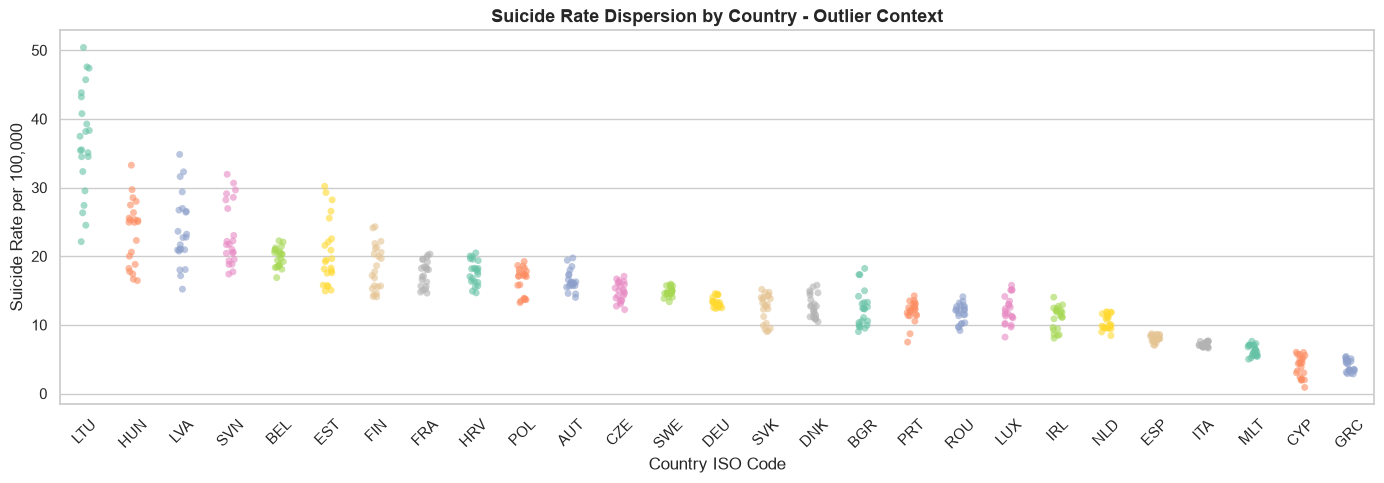

In [106]:
# ==============================================================================
# OUTLIER DETECTION (IQR-based)
# ==============================================================================


def flag_outliers_iqr(df, columns, threshold=1.5):
    """
    Flags rows as outliers using the IQR method for the specified columns.

    Parameters:
    -----------
    df : pd.DataFrame
    columns : list of str
        Columns to check for outliers.
    threshold : float
        IQR multiplier (1.5 = standard, 3.0 = extreme only).

    Returns:
    --------
    pd.DataFrame with count and percentage of outlier rows per feature.
    """
    results = []
    for col in columns:
        if col not in df.columns:
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        results.append(
            {
                "Feature": col,
                "Outlier count": mask.sum(),
                "Outlier %": round(mask.sum() / len(df) * 100, 2),
                "Lower bound": round(lower, 2),
                "Upper bound": round(upper, 2),
            }
        )
    return pd.DataFrame(results).sort_values("Outlier count", ascending=False)


socioeconomic_cols_for_outliers = [
    c for c in social_economic_features if c in df_development.columns
]

outlier_summary = flag_outliers_iqr(df_development, socioeconomic_cols_for_outliers)
print("Outlier Summary (IQR method, threshold=1.5):")
display(outlier_summary)

# Stripplot to visually contextualise suicide rate outliers by country
fig, ax = plt.subplots(figsize=(14, 5))
sns.stripplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
    jitter=True,
    alpha=0.6,
    palette="Set2",
    ax=ax,
)
ax.set_title(
    "Suicide Rate Dispersion by Country - Outlier Context",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Country ISO Code")
ax.set_ylabel("Suicide Rate per 100,000")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Multicollinearity check

Variance Inflation Factor (VIF) - Full predictor set:


,Feature,VIF
0,Autism spectrum disorders,5.007978
1,Attention-deficit/hyperactivity disorder,4.624755
2,Alzheimer's disease and other dementias,3.890342
3,Health expenditure (% GDP),3.756476
4,GDP per capita,3.289503
5,Urban population (%),3.093454
6,Conduct disorder,2.919564
7,Internet users (% of population),2.909881
8,Bipolar disorder,2.867702
9,Alcohol use disorders,2.692689


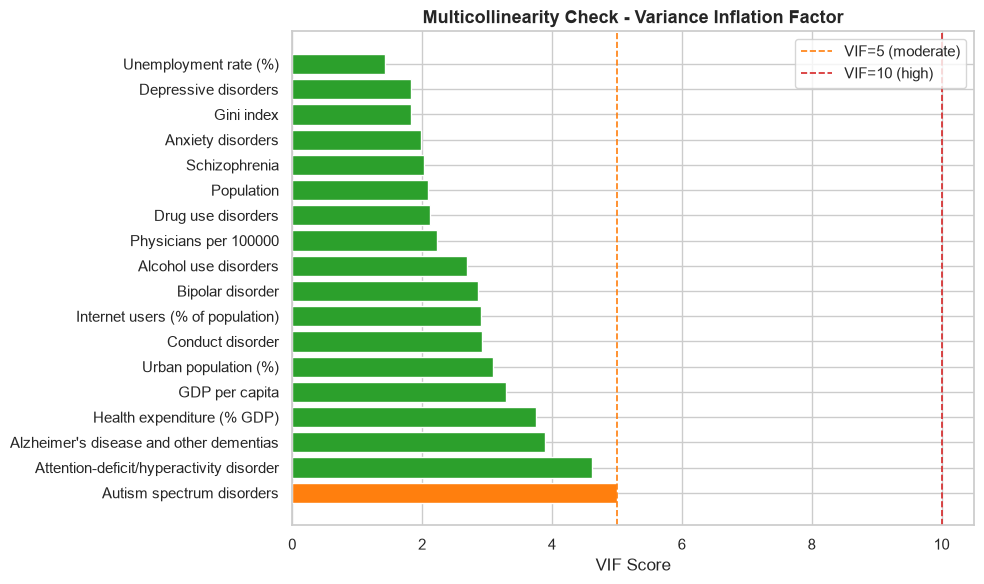

In [110]:
# ==============================================================================
# MULTICOLLINEARITY CHECK (Variance Inflation Factor)
# VIF > 5: moderate concern; VIF > 10: high concern
# ==============================================================================


def compute_vif(df, feature_cols):
    """
    Computes the Variance Inflation Factor (VIF) for each predictor.
    High VIF indicates multicollinearity with other predictors.
    """
    X = df[feature_cols].dropna()
    X_const = add_constant(X)
    vif_data = (
        pd.DataFrame(
            {
                "Feature": X.columns,
                "VIF": [
                    variance_inflation_factor(X_const.values, i + 1)
                    for i in range(len(X.columns))
                ],
            }
        )
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )
    return vif_data


vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

### Addressing high multicollinearity: dropping Eating disorders
Since there is a value with high VIF, meaning it shares so much variance with other predictors that it adds almost no independent information to the model, it is decided to drop 'Eating disorders'

In [109]:
df_development.drop(columns=["Eating disorders"], inplace=True)

vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

KeyError: "['Eating disorders'] not found in axis"

## Two approaches: 
- Option A. Geographical division. In this approach, we take 70% of the countries for training, and we try to predict "unknown" countries with what we learnt from those countries. This way we want to be able to predict the suicide rates of a country only knowing their socioeconomic and health data.
- Option B. Time division. In this approach, we take 70% of the years for all countries for training, and we try to predict the suicide rate in the upcoming years. 

The development dataset (2000–2021) is used for both approaches.
Years 2022–2023 are excluded as WHO suicide rate data is unavailable for that period.

### OPTION A - Geographical division

In [ ]:
np.random.shuffle(EU_countries_iso)

# Division 70% Train, 15% Test, 15% Validation (countries)
total_countries = len(EU_countries_iso)
train_split = int(total_countries * 0.70)
test_split = int(total_countries * 0.85)

train_countries = EU_countries_iso[:train_split]
test_countries = EU_countries_iso[train_split:test_split]
val_countries = EU_countries_iso[test_split:]

# Creating the subsets for Option A
df_train_A = df_development[df_development["Code"].isin(train_countries)].copy()
df_test_A = df_development[df_development["Code"].isin(test_countries)].copy()
df_val_A = df_development[df_development["Code"].isin(val_countries)].copy()

print(f"Train countries ({len(train_countries)}): {train_countries}")
print(f"Test  countries ({len(test_countries)}):  {test_countries}")
print(f"Val   countries ({len(val_countries)}):   {val_countries}")
print(
    f"\nTrain: {len(df_train_A)} rows | Test: {len(df_test_A)} rows | Val: {len(df_val_A)} rows"
)
display(df_train_A.head(3))

Train countries (18): ['SVK', 'BGR', 'LUX', 'IRL', 'ROU', 'DNK', 'EST', 'GRC', 'HUN', 'FRA', 'ITA', 'AUT', 'POL', 'FIN', 'SVN', 'NLD', 'DEU', 'HRV']
Test  countries (4):  ['ESP', 'CZE', 'CYP', 'MLT']
Val   countries (5):   ['PRT', 'LTU', 'LVA', 'SWE', 'BEL']

Train: 396 rows | Test: 88 rows | Val: 110 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

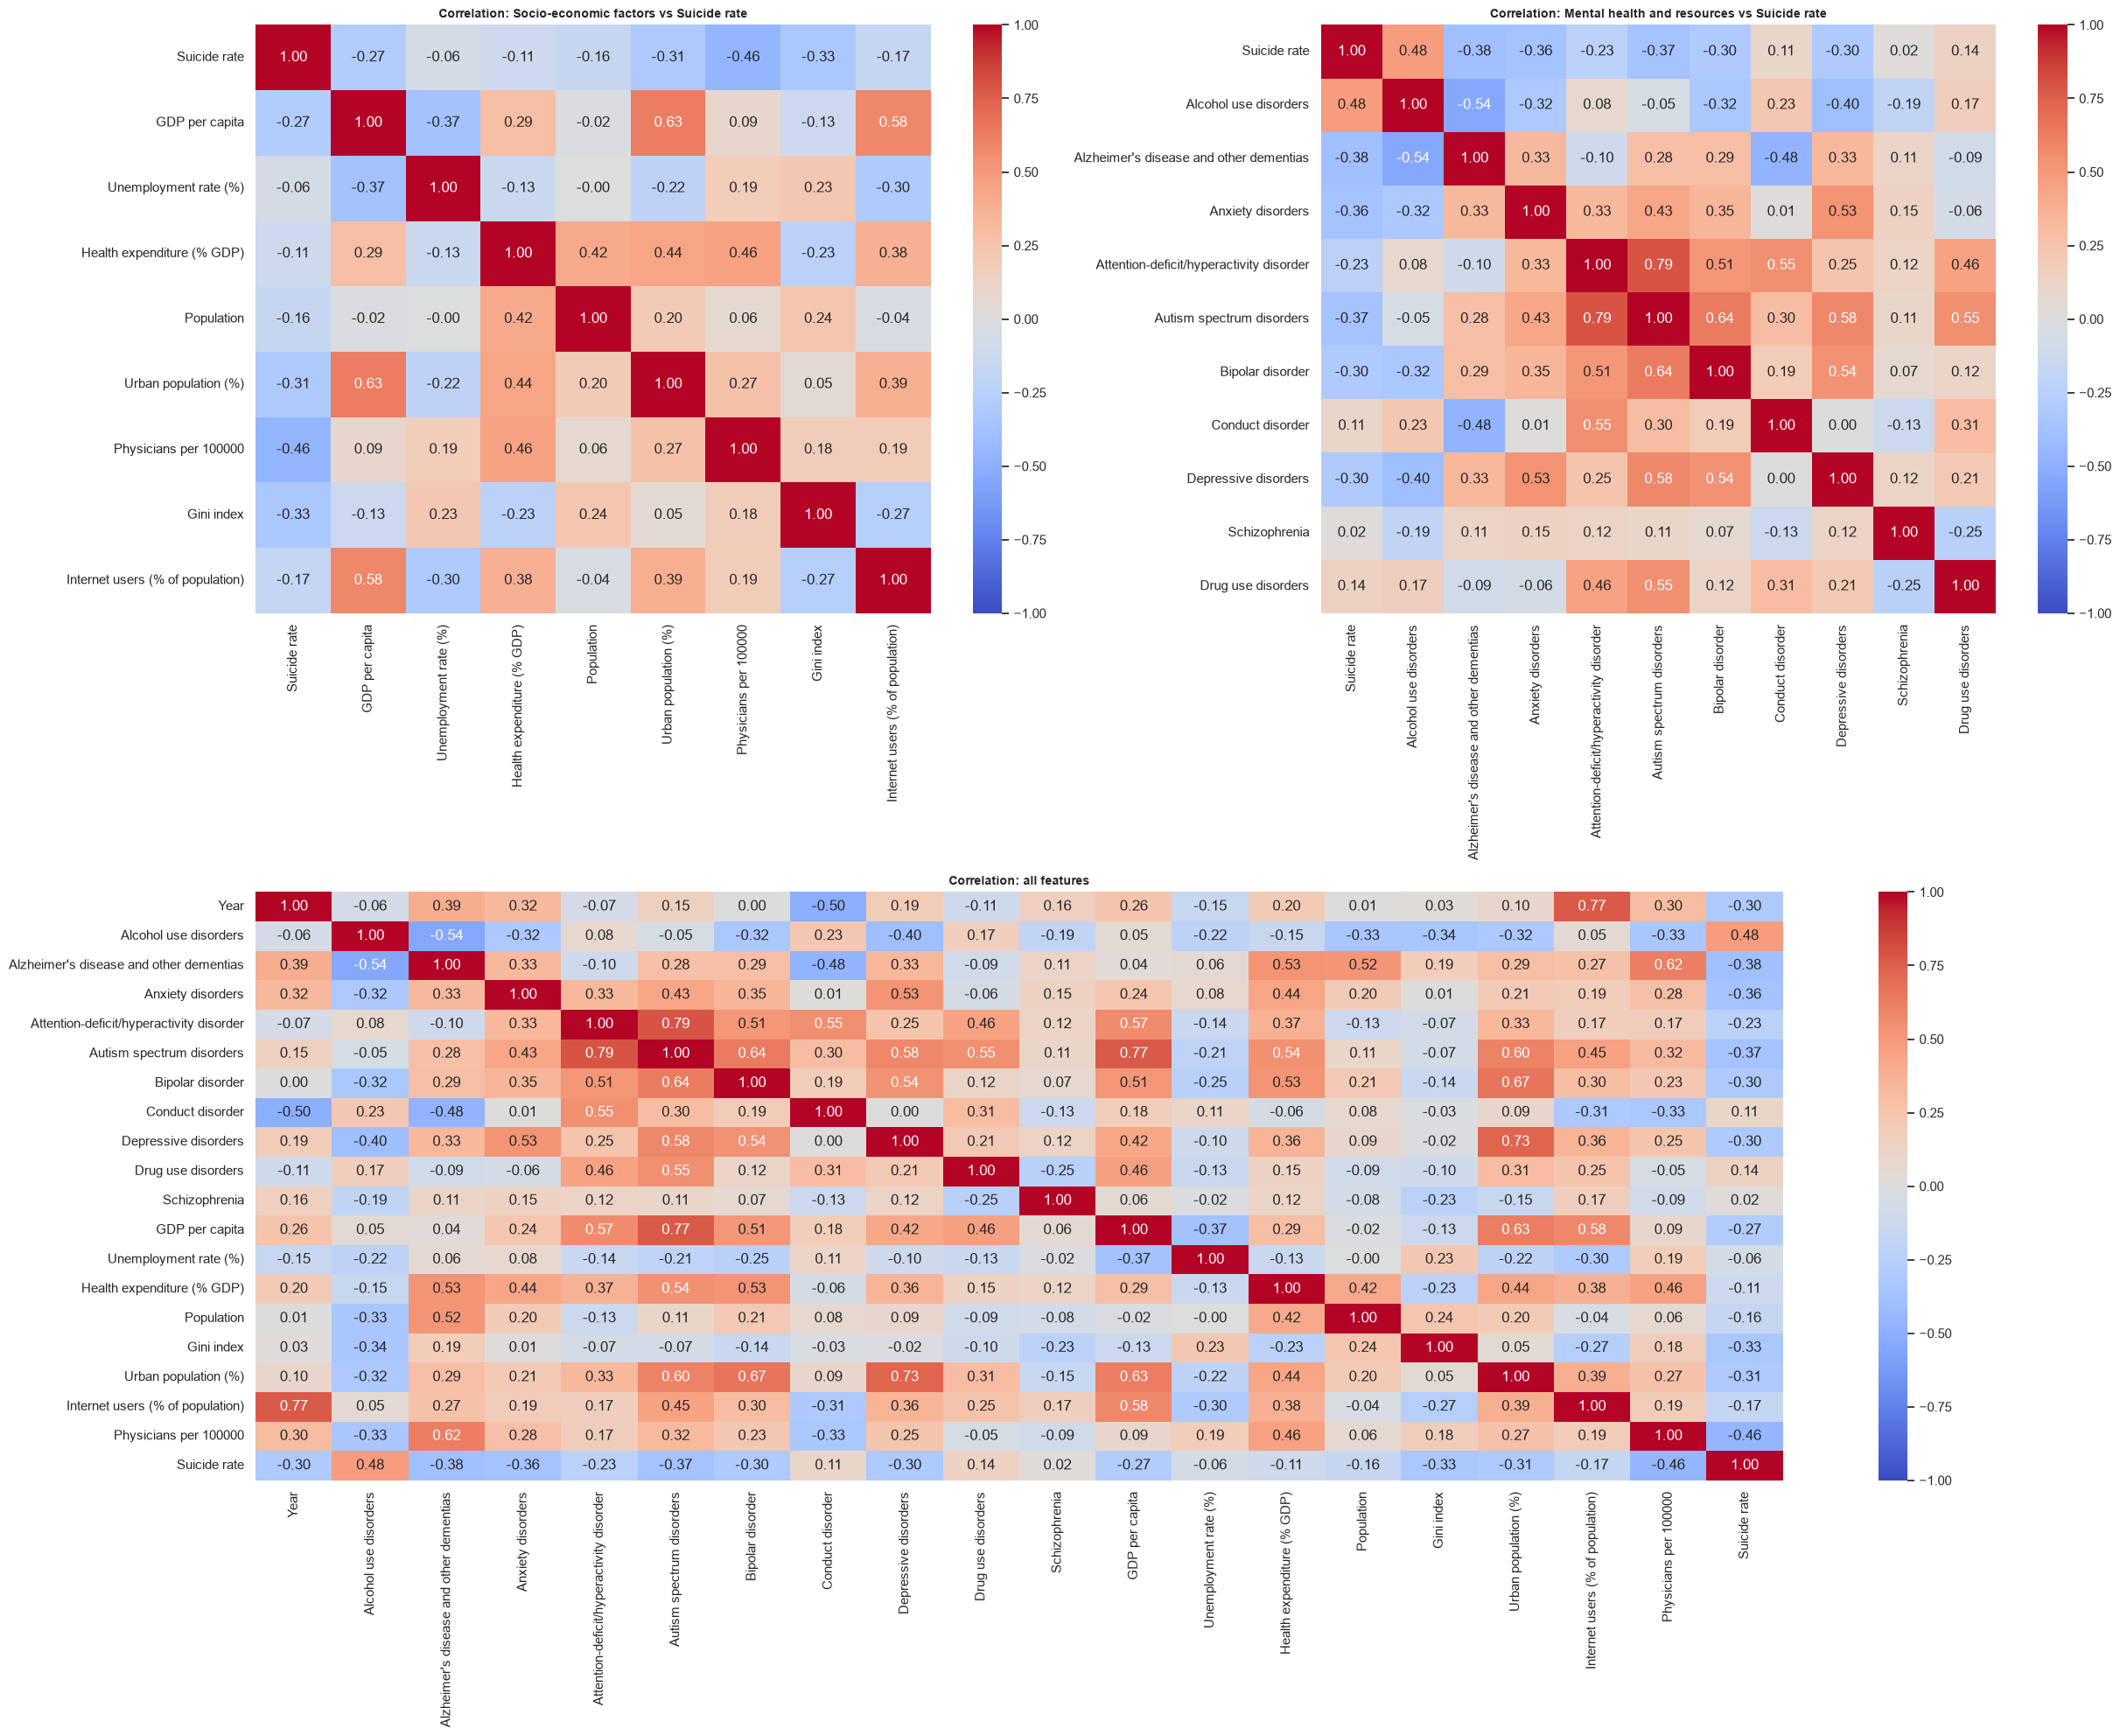

In [ ]:
# ==============================================================================
# CORRELATION ANALYSIS
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_A[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_A[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_A.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set A

In [ ]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option A: fit on train_A, transform test_A and val_A
scaler_A = RobustScaler()

X_train_A = df_train_A[predictor_features].copy()
X_test_A = df_test_A[predictor_features].copy()
X_val_A = df_val_A[predictor_features].copy()

y_train_A = df_train_A[TARGET].copy()
y_test_A = df_test_A[TARGET].copy()
y_val_A = df_val_A[TARGET].copy()

X_train_A_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_train_A),
    columns=predictor_features,
    index=X_train_A.index,
)
X_test_A_scaled = pd.DataFrame(
    scaler_A.transform(X_test_A),
    columns=predictor_features,
    index=X_test_A.index,
)
X_val_A_scaled = pd.DataFrame(
    scaler_A.transform(X_val_A),
    columns=predictor_features,
    index=X_val_A.index,
)

print(" OPTION A - Scaled dataset shapes")
print(f"X_train_A: {X_train_A_scaled.shape}  |  y_train_A: {y_train_A.shape}")
print(f"X_test_A:  {X_test_A_scaled.shape}   |  y_test_A:  {y_test_A.shape}")
print(f"X_val_A:   {X_val_A_scaled.shape}    |  y_val_A:   {y_val_A.shape}")
display(X_train_A_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train A) — median ~0, IQR ~1:")
sanity_A = pd.DataFrame(
    {
        "Median": X_train_A_scaled.median().round(3),
        "IQR": (
            X_train_A_scaled.quantile(0.75) - X_train_A_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_A)

 OPTION A - Scaled dataset shapes
X_train_A: (396, 18)  |  y_train_A: (396,)
X_test_A:  (88, 18)   |  y_test_A:  (88,)
X_val_A:   (110, 18)    |  y_val_A:   (110,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,396.0,0.008,0.698,-1.280,-0.436,0.0,0.564,1.401
Alzheimer's disease and other dementias,396.0,0.190,0.915,-1.106,-0.451,-0.0,0.549,3.238
Anxiety disorders,396.0,0.154,0.760,-1.101,-0.405,0.0,0.595,3.272
Attention-deficit/hyperactivity disorder,396.0,0.153,0.569,-0.632,-0.335,-0.0,0.665,1.641
Autism spectrum disorders,396.0,-0.110,0.560,-0.993,-0.672,0.0,0.328,1.193
Bipolar disorder,396.0,-0.020,0.557,-0.981,-0.526,0.0,0.474,1.100
Conduct disorder,396.0,0.062,0.699,-1.210,-0.496,0.0,0.504,2.507
Depressive disorders,396.0,0.137,0.802,-0.912,-0.501,0.0,0.499,3.584
Drug use disorders,396.0,0.007,0.846,-1.920,-0.534,-0.0,0.466,2.371
Schizophrenia,396.0,-0.025,1.171,-3.141,-0.556,0.0,0.444,3.083



Scaling sanity check (train A) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,-0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,-0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,-0.0,1.0
Schizophrenia,0.0,1.0


### OPTION B - Time division
All 27 countries are included across all splits. The model learns temporal patterns from earlier years and is evaluated on its ability to generalise to more recent periods.

In [ ]:
# Division 70% Train, 15% Test, 15% Validation (years)
year_range = sorted(df_development["Year"].unique())
total_years = len(year_range)
train_split = int(total_years * 0.70)
test_split = int(total_years * 0.85)

train_years = year_range[:train_split]
test_years = year_range[train_split:test_split]
val_years = year_range[test_split:]

# Creating the subsets for Option B
df_train_B = df_development[df_development["Year"].isin(train_years)].copy()
df_test_B = df_development[df_development["Year"].isin(test_years)].copy()
df_val_B = df_development[df_development["Year"].isin(val_years)].copy()

print(f"Train years: {train_years}")
print(f"Test  years: {test_years}")
print(f"Val   years: {val_years}")
print(
    f"\nTrain: {len(df_train_B)} rows | Test: {len(df_test_B)} rows | Val: {len(df_val_B)} rows"
)
display(df_train_B.head(3))

Train years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Test  years: [np.int64(2015), np.int64(2016), np.int64(2017)]
Val   years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Train: 405 rows | Test: 81 rows | Val: 108 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

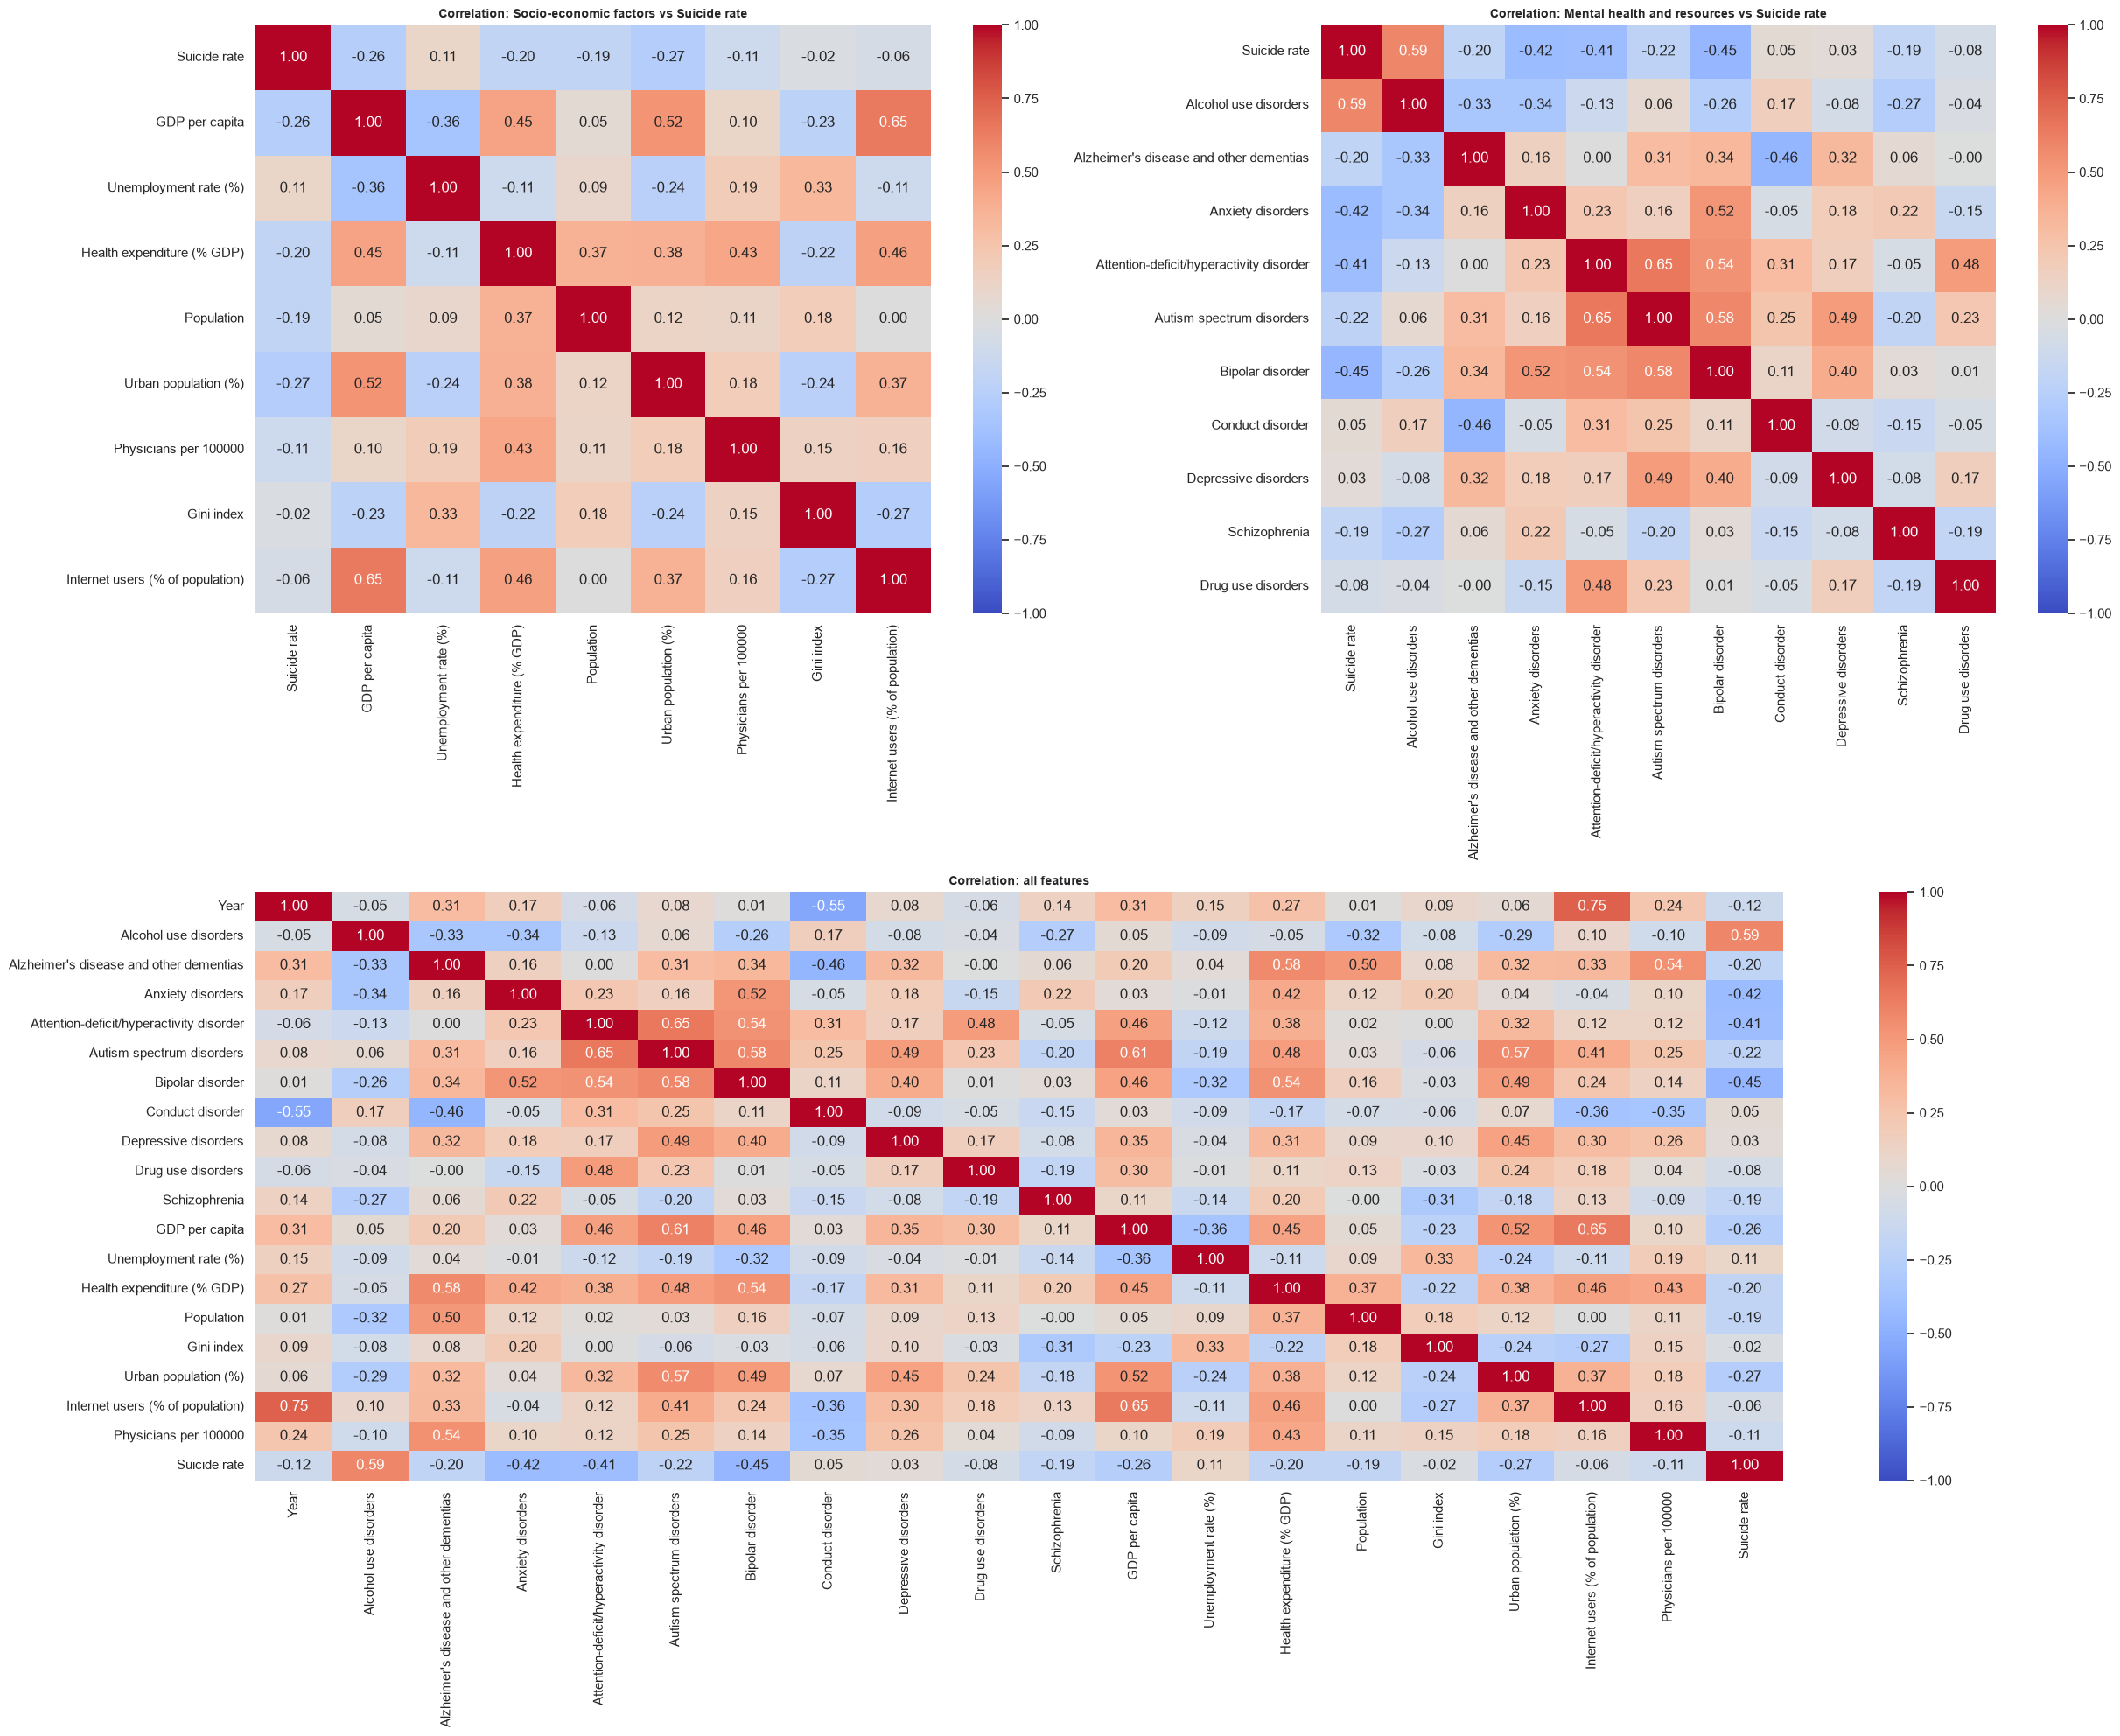

In [ ]:
# ==============================================================================
# CORRELATION ANALYSIS FOR SET B
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_B[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_B[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_B.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set B

In [ ]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option B: fit on train_B, transform test_B and val_B
scaler_B = RobustScaler()

X_train_B = df_train_B[predictor_features].copy()
X_test_B = df_test_B[predictor_features].copy()
X_val_B = df_val_B[predictor_features].copy()

y_train_B = df_train_B[TARGET].copy()
y_test_B = df_test_B[TARGET].copy()
y_val_B = df_val_B[TARGET].copy()

X_train_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_train_B),
    columns=predictor_features,
    index=X_train_B.index,
)
X_test_B_scaled = pd.DataFrame(
    scaler_B.transform(X_test_B),
    columns=predictor_features,
    index=X_test_B.index,
)
X_val_B_scaled = pd.DataFrame(
    scaler_B.transform(X_val_B),
    columns=predictor_features,
    index=X_val_B.index,
)

print(" OPTION B - Scaled dataset shapes")
print(f"X_train_B: {X_train_B_scaled.shape}  |  y_train_B: {y_train_B.shape}")
print(f"X_test_B:  {X_test_B_scaled.shape}   |  y_test_B:  {y_test_B.shape}")
print(f"X_val_B:   {X_val_B_scaled.shape}    |  y_val_B:   {y_val_B.shape}")
display(X_train_B_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train B) — median ~0, IQR ~1:")
sanity_B = pd.DataFrame(
    {
        "Median": X_train_B_scaled.median().round(3),
        "IQR": (
            X_train_B_scaled.quantile(0.75) - X_train_B_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_B)

 OPTION B - Scaled dataset shapes
X_train_B: (405, 18)  |  y_train_B: (405,)
X_test_B:  (81, 18)   |  y_test_B:  (81,)
X_val_B:   (108, 18)    |  y_val_B:   (108,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,405.0,-0.002,0.657,-1.215,-0.474,0.0,0.526,1.197
Alzheimer's disease and other dementias,405.0,0.167,0.785,-1.054,-0.434,0.0,0.566,3.163
Anxiety disorders,405.0,0.213,0.795,-1.013,-0.364,0.0,0.636,2.994
Attention-deficit/hyperactivity disorder,405.0,-0.089,0.661,-1.057,-0.681,0.0,0.319,1.633
Autism spectrum disorders,405.0,-0.189,0.621,-1.195,-0.841,0.0,0.159,1.508
Bipolar disorder,405.0,-0.124,0.582,-1.178,-0.698,0.0,0.302,1.135
Conduct disorder,405.0,0.054,0.791,-1.549,-0.486,0.0,0.514,2.529
Depressive disorders,405.0,0.006,0.690,-1.058,-0.560,0.0,0.440,2.324
Drug use disorders,405.0,0.068,0.886,-1.921,-0.541,0.0,0.459,3.414
Schizophrenia,405.0,-0.108,0.936,-1.943,-0.534,0.0,0.466,2.410



Scaling sanity check (train B) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,0.0,1.0
Schizophrenia,0.0,1.0


## Model Training
 
This section covers the training and evaluation of four regression models
applied to both split approaches defined in the EDA:
 
- **Option A** — Geographical split (70/15/15 by country)
- **Option B** — Time split (70/15/15 by year)
 
The models are trained using **GridSearchCV**, which performs an exhaustive
search over a predefined hyperparameter grid using k-fold cross-validation
*exclusively within the training set*, ensuring the test and validation sets
remain completely unseen during model selection.
 
The four models selected cover a spectrum from interpretable linear baselines
to a powerful non-parametric ensemble, allowing a meaningful comparison of
both predictive performance and analytical insight.

### Cross-Validation Strategy
 
GridSearchCV is the standard academic method for hyperparameter selection.
It evaluates every combination in the grid using k-fold cross-validation
inside the training set, preventing the test and validation sets from
influencing any modelling decisions.
 
**Why GridSearchCV is valid here:**
- It separates *model selection* (inside train) from *model evaluation*
  (on test/val), preventing hyperparameter overfitting.
- Every combination is evaluated under identical conditions, making the
  search exhaustive and reproducible given a fixed random seed.
- The best estimator is automatically refit on the full training set after
  the search (`refit=True`), maximising the information used for training.
 
**CV strategy per approach:**
 
| Approach | Strategy | Justification |
|---|---|---|
| Option A (geographical) | Standard 5-fold | Countries are independent observations — no temporal ordering to preserve |
| Option B (time split) | `TimeSeriesSplit(n_splits=5)` | Standard k-fold would shuffle folds randomly, allowing future data to appear in training — a form of temporal data leakage. TimeSeriesSplit always uses earlier data for training and later data for validation within each fold |
 
**Primary evaluation metric:** Root Mean Squared Error (RMSE), which is
expressed in the same units as the target variable (suicide rate per 100,000
inhabitants), making results directly interpretable.
 
$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
 
Secondary metrics reported: Mean Absolute Error (MAE) and the coefficient
of determination ($R^2$).
 
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
 
$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

### Model 1 — Ridge Regression
 
#### Definition
 
Ridge Regression is a regularised extension of Ordinary Least Squares (OLS)
that addresses overfitting by adding an **L2 penalty** on the magnitude of
the coefficients to the loss function. It is the natural starting point for
any regression analysis as it provides a fully interpretable linear baseline
while being robust to moderate multicollinearity.
 
#### Loss Function
 
$$\mathcal{L}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{OLS loss}} + \underbrace{\alpha \|\beta\|^2_2}_{\text{L2 penalty}}$$
 
where $\alpha \geq 0$ is the regularisation strength and
$\|\beta\|^2_2 = \sum_{j=1}^{p} \beta_j^2$ is the squared L2 norm.
 
#### Closed-Form Solution
 
Unlike most machine learning models, Ridge admits an exact analytical solution:
 
$$\hat{\beta}^{\text{Ridge}} = (X^TX + \alpha I)^{-1} X^T y$$
 
Adding $\alpha I$ to $X^TX$ guarantees invertibility even when features are
correlated, which is one of the key motivations for regularisation.
 
#### Behaviour
 
- All coefficients are **shrunk toward zero** but never exactly zeroed.
- As $\alpha \to 0$, Ridge converges to OLS.
- As $\alpha \to \infty$, all coefficients shrink to zero.
- Coefficients remain comparable in magnitude after `RobustScaler`,
  making their values directly interpretable as feature contributions.
 
#### Hyperparameter Grid
 
| Parameter | Values searched | Rationale |
|---|---|---|
| `alpha` | `[0.01, 0.1, 1, 10, 100, 1000]` | Log-scale search spanning from near-OLS (0.01) to strong regularisation (1000). Log scale is appropriate because alpha's effect is multiplicative |

### Model 2 — Lasso Regression
 
#### Definition
 
Lasso (Least Absolute Shrinkage and Selection Operator) is a regularised
regression model that uses an **L1 penalty** instead of L2. The key
distinction from Ridge is that the L1 penalty has the geometric property
of producing **sparse solutions** — it drives some coefficients exactly to
zero, performing automatic feature selection.
 
#### Loss Function
 
$$\mathcal{L}(\beta) = \underbrace{\|y - X\beta\|^2}_{\text{OLS loss}} + \underbrace{\alpha \|\beta\|_1}_{\text{L1 penalty}}$$
 
where $\|\beta\|_1 = \sum_{j=1}^{p} |\beta_j|$ is the L1 norm.
 
#### No Closed-Form Solution
 
Unlike Ridge, the absolute value in the L1 penalty makes
$\mathcal{L}(\beta)$ non-differentiable at $\beta_j = 0$. There is no
closed-form solution; instead, **coordinate descent** is used, minimising
the loss with respect to one coefficient at a time while holding all others
fixed, cycling until convergence.
 
#### Why Lasso Complements Ridge
 
| Property | Ridge | Lasso |
|---|---|---|
| Penalty | $\|\beta\|^2_2$ | $\|\beta\|_1$ |
| Solution sparsity | Never zero | Can be exactly zero |
| Feature selection | No | Yes |
| Closed form | Yes | No |
| Best when | All features contribute | Some features are redundant |
 
In this analysis, the non-zero Lasso coefficients identify which
socioeconomic and mental health determinants carry **independent predictive
signal** after controlling for all others — a direct answer to the thesis
research question.
 
#### Hyperparameter Grid
 
| Parameter | Values searched | Rationale |
|---|---|---|
| `alpha` | `[0.001, 0.01, 0.1, 1, 10, 100]` | Lower bound extended to 0.001 vs Ridge because Lasso requires smaller alpha values to preserve most features non-zero on a standardised dataset |

### Model 3 — Support Vector Regression (SVR)
 
#### Definition
 
Support Vector Regression extends the Support Vector Machine framework to
continuous targets. Rather than minimising prediction error directly, SVR
finds a function $f(x)$ that deviates from the true values $y_i$ by **at
most $\varepsilon$**, while being as flat (generalising) as possible.
This introduces a fundamentally different philosophy from the linear models:
predictions within a tube of width $2\varepsilon$ around the true value
incur **zero loss**.
 
#### Primal Optimisation Problem
 
$$\min_{w, b, \xi, \xi^*} \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{n}(\xi_i + \xi_i^*)$$
 
subject to:
 
$$y_i - w^T x_i - b \leq \varepsilon + \xi_i$$
$$w^T x_i + b - y_i \leq \varepsilon + \xi_i^*$$
$$\xi_i, \xi_i^* \geq 0$$
 
where $\xi_i, \xi_i^*$ are slack variables allowing predictions to exceed
the $\varepsilon$-tube, penalised by $C$.
 
#### The Kernel Trick
 
SVR is solved in its **dual formulation**, where the data only appears
through inner products $\langle x_i, x_j \rangle$. Replacing these with a
kernel function $K(x_i, x_j)$ implicitly maps the data to a
higher-dimensional space without ever computing the mapping explicitly:
 
$$f(x) = \sum_{i=1}^{n} (\alpha_i - \alpha_i^*) K(x_i, x) + b$$
 
The **Radial Basis Function (RBF) kernel** used here is:
 
$$K(x_i, x_j) = \exp\left(-\gamma \|x_i - x_j\|^2\right)$$
 
which measures similarity as a Gaussian function of Euclidean distance —
nearby points in feature space are considered highly similar regardless of
how many dimensions that space has.
 
#### Hyperparameter Grid
 
| Parameter | Values searched | Rationale |
|---|---|---|
| `C` | `[0.1, 1, 10, 100]` | Trade-off between margin flatness and tolerance of violations. Low C = wider tube = simpler model; high C = tighter fit = risk of overfitting |
| `epsilon` | `[0.1, 0.5, 1.0]` | Width of the insensitive tube. Values are chosen relative to the target scale (suicide rate per 100,000): 0.1 is tight, 1.0 allows ~1 unit of error with no penalty |
| `kernel` | `['linear', 'rbf']` | Tests whether the relationship is linear in feature space (linear) or requires non-linear similarity (rbf) |

### Model 4 — Random Forest Regressor
 
#### Definition
 
Random Forest is a **bagging ensemble** of Decision Trees. It addresses
the fundamental weakness of a single Decision Tree — high variance and
tendency to overfit — by training many trees on different random subsets
of the data and averaging their predictions.
 
#### Building Each Tree
 
For each of the $B$ trees in the forest:
 
1. Draw a **bootstrap sample** $\mathcal{D}_b$ of size $n$ from the
   training set (sampling with replacement).
2. At each node, consider only a random subset of
   $m = \lfloor\sqrt{p}\rfloor$ features (where $p$ is the total number
   of features) as candidates for the split.
3. Choose the split that minimises the weighted MSE of the child nodes:
 
$$\text{MSE}_{\text{split}} = \frac{n_L}{n} \cdot \text{Var}(y_L) + \frac{n_R}{n} \cdot \text{Var}(y_R)$$
 
4. Grow the tree to maximum depth (or until a stopping criterion is met).
 
#### Prediction
 
The final prediction is the average across all trees:
 
$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} f_b(x)$$
 
#### Why Averaging Works
 
By restricting each tree to a random feature subset, the trees are
**decorrelated** — they make different errors on different parts of the
input space. Averaging decorrelated estimators reduces variance without
increasing bias, which is the core of the bias-variance trade-off improvement.
 
#### Feature Importance
 
Random Forest computes **impurity-based feature importance** as the total
reduction in MSE attributable to splits on each feature, averaged across
all trees and weighted by the number of samples at each node. This directly
addresses the thesis research question by ranking which determinants most
reduce prediction error across the full ensemble.
 
#### Hyperparameter Grid
 
| Parameter | Values searched | Rationale |
|---|---|---|
| `n_estimators` | `[100, 200, 300]` | More trees reduce variance up to a point. 100 is sufficient for stability; 300 is the practical upper bound for this dataset size |
| `max_depth` | `[5, 10, 15, None]` | Controls tree complexity. `None` grows full trees; smaller depths prevent overfitting by limiting how specific each tree becomes |
| `min_samples_split` | `[2, 5, 10]` | Minimum samples needed to split a node. Higher values force more general splits |
| `max_features` | `['sqrt', 0.5]` | Fraction of features considered at each split. `'sqrt'` is the theoretical default; `0.5` is a common alternative that increases decorrelation |

In [ ]:
# ==============================================================================
# Hyperparameter grids and model instances
# ==============================================================================

param_grids = {
    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    },
    "Lasso": {
        "alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    },
    "SVR": {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.1, 0.5, 1.0],
        "kernel": ["linear", "rbf"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", 0.5],
    },
}

models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
}

In [ ]:
# ==============================================================================
# Model training and evaluation functions creation and definition
# ==============================================================================


def train_model(name, model, param_grid, X_train, y_train, cv):
    """
    Runs GridSearchCV for a single model and returns the best estimator
    along with training metadata. Evaluation is handled separately by
    evaluate_model(), keeping the two concerns cleanly separated.

    Parameters:
    -----------
    name       : str          — model name, used for display only
    model      : estimator    — unfitted sklearn-compatible model instance
    param_grid : dict         — hyperparameter grid for GridSearchCV
    X_train    : pd.DataFrame — scaled training features
    y_train    : pd.Series    — training target values
    cv         : int or CV    — cross-validation strategy:
                                int for standard k-fold (Option A),
                                TimeSeriesSplit object (Option B)

    # Returns:
    --------
    dict with keys:
      'name'           : model name
      'best_estimator' : fitted best model (refit on full training set)
      'best_params'    : hyperparameter combination selected by GridSearchCV
      'cv_rmse'        : mean CV RMSE of the best combination (positive)
      'time_s'         : total wall-clock training time in seconds
    """
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(
        f"  Grid size: {len(param_grid)} params | "
        f"Combinations: "
        f"{__import__('math').prod(len(v) for v in param_grid.values())}"
    )
    print(f"{'='*60}")

    start = time.time()

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,  # parallelise across all available CPU cores
        refit=True,  # refit best config on full training set
        verbose=0,
    )
    search.fit(X_train, y_train)

    elapsed = round(time.time() - start, 2)
    cv_rmse = round(-search.best_score_, 4)

    print(f"  Best params : {search.best_params_}")
    print(f"  CV RMSE     : {cv_rmse}")
    print(f"  Training time: {elapsed}s")

    return {
        "name": name,
        "best_estimator": search.best_estimator_,
        "best_params": search.best_params_,
        "cv_rmse": cv_rmse,
        "time_s": elapsed,
    }


def evaluate_model(trained, X, y, split_label):
    """
    Evaluates a trained model on a given dataset split and returns a metrics
    dictionary. Intentionally separated from train_model() so that each model
    can be evaluated on any number of splits (test, val, etc.) independently.

    Parameters:
    -----------
    trained    : dict         — output of train_model()
    X          : pd.DataFrame — scaled features for the split to evaluate
    y          : pd.Series    — true target values for the split
    split_label: str          — human-readable label for display (e.g. "Test A")

    Returns:
    --------
    dict with keys:
      'model'      : model name
      'split'      : split label
      'rmse'       : Root Mean Squared Error
      'mae'        : Mean Absolute Error
      'r2'         : Coefficient of determination R²
      'predictions': np.array of predicted values (for plotting)
      'actuals'    : np.array of true values (for plotting)
    """
    model = trained["best_estimator"]
    name = trained["name"]
    y_pred = model.predict(X)

    rmse = round(np.sqrt(mean_squared_error(y, y_pred)), 4)
    mae = round(mean_absolute_error(y, y_pred), 4)
    r2 = round(r2_score(y, y_pred), 4)

    print(
        f"  {name:20s} | {split_label:10s} — "
        f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}"
    )

    return {
        "model": name,
        "split": split_label,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "predictions": y_pred,
        "actuals": y.values,
    }

### Option A — Geographical Split: Model Training
 
Each model is trained on `X_train_A_scaled` and `y_train_A` using standard
5-fold cross-validation. Countries are treated as independent observations,
so there is no temporal structure to preserve within the folds.
 
After training, each model is evaluated separately on:
- **Test set** — countries held out during training (seen for first time)
- **Validation set** — remaining held-out countries (final performance estimate)

In [ ]:
cv_A = 5  # standard k-fold: countries are independent observations

trained_A = {}

print("OPTION A — TRAINING")
for name in models:
    trained_A[name] = train_model(
        name=name,
        model=models[name],
        param_grid=param_grids[name],
        X_train=X_train_A_scaled,
        y_train=y_train_A,
        cv=cv_A,
    )

eval_A = []

print("\nOPTION A — EVALUATION")
print(f"{'='*60}")

for name in trained_A:
    eval_A.append(evaluate_model(trained_A[name], X_test_A_scaled, y_test_A, "Test"))
    eval_A.append(evaluate_model(trained_A[name], X_val_A_scaled, y_val_A, "Val"))

OPTION A — TRAINING

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 1000}
  CV RMSE     : 5.2577
  Training time: 9.83s

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 1}
  CV RMSE     : 5.5538
  Training time: 0.05s

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 1, 'epsilon': 1.0, 'kernel': 'rbf'}
  CV RMSE     : 5.3184
  Training time: 0.56s

  Training: Random Forest
  Grid size: 4 params | Combinations: 72
  Best params : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
  CV RMSE     : 5.4215
  Training time: 17.99s

OPTION A — EVALUATION
  Ridge                | Test       — RMSE: 7.0672 | MAE: 5.9878 | R²: -1.8218
  Ridge                | Val        — RMSE: 11.7065 | MAE: 7.8321 | R²: -0.4775
  Lasso                | Test       — RMSE: 7.0820 | MAE: 5.9829 | R²: -1.8337
  Lasso                | Val        — RMSE: 11.4366 | MAE: 7.5224 | R

### Option B — Time Split: Model Training
 
Each model is trained on `X_train_B_scaled` and `y_train_B` using
`TimeSeriesSplit(n_splits=5)` as the cross-validation strategy.
 
Standard k-fold would randomly assign years to folds, which would allow
a model to be trained on data from 2018 and validated on data from 2010 —
using future information to predict the past. `TimeSeriesSplit` prevents
this by ensuring that within each fold, **all training years precede all
validation years**, preserving the chronological integrity of the data.
 
After training, each model is evaluated on:
- **Test set** — years 2016–2018 (unseen during training)
- **Validation set** — years 2019–2021 (final performance estimate)

In [ ]:
cv_B = TimeSeriesSplit(n_splits=5)

trained_B = {}

print("OPTION B — TRAINING")
for name in models:
    trained_B[name] = train_model(
        name=name,
        model=models[name],
        param_grid=param_grids[name],
        X_train=X_train_B_scaled,
        y_train=y_train_B,
        cv=cv_B,
    )

eval_B = []

print("\nOPTION B — EVALUATION")
print(f"{'='*60}")

for name in trained_B:
    eval_B.append(evaluate_model(trained_B[name], X_test_B_scaled, y_test_B, "Test"))
    eval_B.append(evaluate_model(trained_B[name], X_val_B_scaled, y_val_B, "Val"))

OPTION B — TRAINING

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 1000}
  CV RMSE     : 7.8349
  Training time: 0.05s

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 1}
  CV RMSE     : 7.5511
  Training time: 0.05s

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
  CV RMSE     : 6.5417
  Training time: 0.48s

  Training: Random Forest
  Grid size: 4 params | Combinations: 72
  Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
  CV RMSE     : 6.9333
  Training time: 16.54s

OPTION B — EVALUATION
  Ridge                | Test       — RMSE: 5.2058 | MAE: 4.0774 | R²: 0.1821
  Ridge                | Val        — RMSE: 4.5030 | MAE: 3.5798 | R²: 0.0845
  Lasso                | Test       — RMSE: 4.8137 | MAE: 3.8855 | R²: 0.3007
  Lasso                | Val        — RMSE: 4.2053 | MAE: 3.5016 | R²: 

### Results
 
The following tables and charts summarise model performance across both
approaches, split types, and evaluation metrics.
 
Models are ranked by **Test RMSE** (ascending) as the primary criterion,
since the test set represents a genuinely unseen evaluation that was not
used in any model selection decision. Validation RMSE is reported as the
final performance estimate.
 
A large gap between CV RMSE and Test RMSE suggests overfitting to the
training distribution. A large gap between Test RMSE and Val RMSE suggests
sensitivity to which specific countries (A) or years (B) were held out.

In [ ]:
# ==============================================================================
# Results comparison tables
# ==============================================================================


def build_results_table(eval_list, trained_dict, split_filter, approach_label):
    """
    Builds a comparison DataFrame from evaluation results.

    Parameters:
    -----------
    eval_list     : list of dicts — output of evaluate_model() calls
    trained_dict  : dict          — output of train_model() calls (for CV RMSE)
    split_filter  : str           — 'Test' or 'Val'
    approach_label: str           — label for display

    Returns:
    --------
    pd.DataFrame sorted by RMSE ascending.
    """
    rows = []
    for r in eval_list:
        if r["split"] != split_filter:
            continue
        rows.append(
            {
                "Model": r["model"],
                "CV RMSE": trained_dict[r["model"]]["cv_rmse"],
                "RMSE": r["rmse"],
                "MAE": r["mae"],
                "R²": r["r2"],
                "Time (s)": trained_dict[r["model"]]["time_s"],
            }
        )
    df = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
    print(f"\n{approach_label} — {split_filter} set results:")
    display(df)
    return df


# Option A tables
table_A_test = build_results_table(eval_A, trained_A, "Test", "Option A")
table_A_val = build_results_table(eval_A, trained_A, "Val", "Option A")

# Option B tables
table_B_test = build_results_table(eval_B, trained_B, "Test", "Option B")
table_B_val = build_results_table(eval_B, trained_B, "Val", "Option B")


Option A — Test set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,Random Forest,5.4215,5.6185,4.6169,-0.7836,17.99
1,SVR,5.3184,5.8929,5.1784,-0.9620,0.56
2,Ridge,5.2577,7.0672,5.9878,-1.8218,9.83
3,Lasso,5.5538,7.0820,5.9829,-1.8337,0.05



Option A — Val set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,Random Forest,5.4215,10.6428,6.9705,-0.2212,17.99
1,SVR,5.3184,11.3416,7.7478,-0.3868,0.56
2,Lasso,5.5538,11.4366,7.5224,-0.4102,0.05
3,Ridge,5.2577,11.7065,7.8321,-0.4775,9.83



Option B — Test set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,SVR,6.5417,2.1226,1.5895,0.8640,0.48
1,Random Forest,6.9333,2.4022,1.8126,0.8259,16.54
2,Lasso,7.5511,4.8137,3.8855,0.3007,0.05
3,Ridge,7.8349,5.2058,4.0774,0.1821,0.05



Option B — Val set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,SVR,6.5417,2.8483,2.1567,0.6337,0.48
1,Random Forest,6.9333,3.0774,2.4508,0.5724,16.54
2,Lasso,7.5511,4.2053,3.5016,0.2015,0.05
3,Ridge,7.8349,4.5030,3.5798,0.0845,0.05


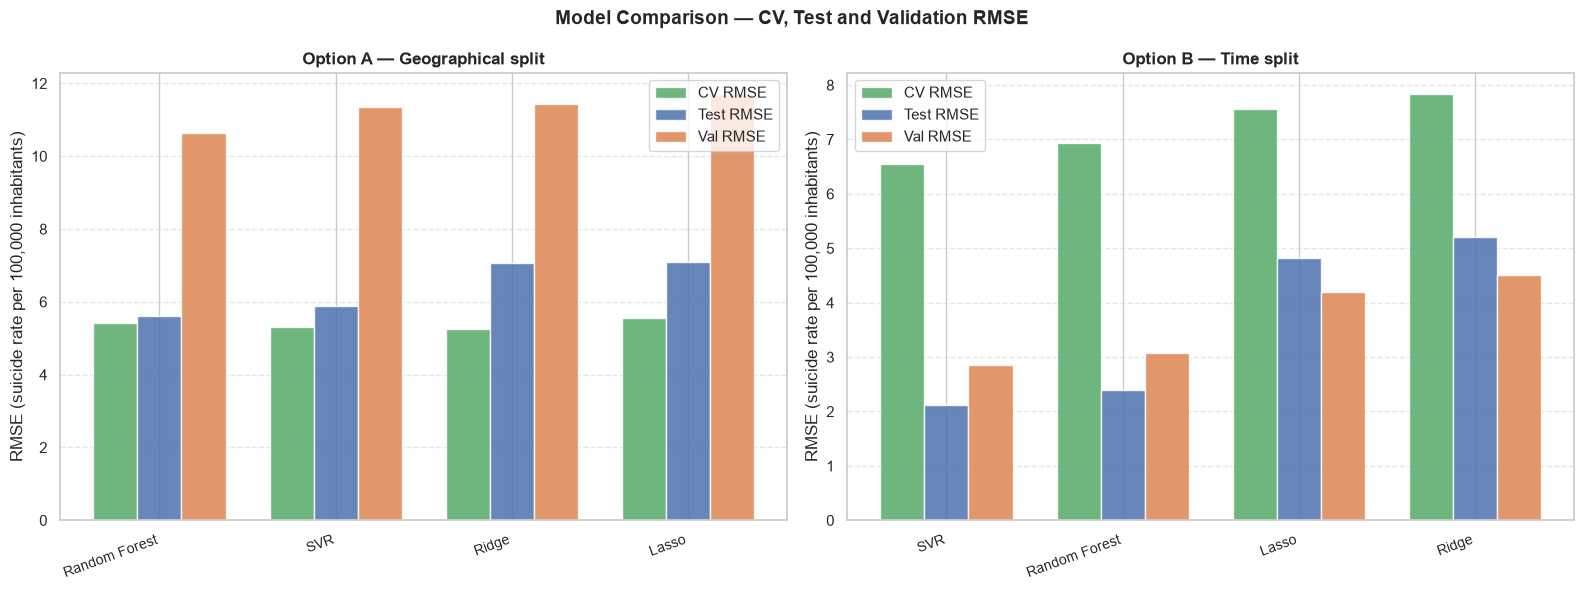

In [ ]:
# ==============================================================================
# RMSE comparison bar chart
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, test_tbl, val_tbl, label in zip(
    axes,
    [table_A_test, table_B_test],
    [table_A_val, table_B_val],
    ["Option A — Geographical split", "Option B — Time split"],
):
    x = np.arange(len(test_tbl))
    width = 0.25

    ax.bar(
        x - width,
        test_tbl["CV RMSE"],
        width,
        label="CV RMSE",
        color="#55A868",
        alpha=0.85,
    )
    ax.bar(x, test_tbl["RMSE"], width, label="Test RMSE", color="#4C72B0", alpha=0.85)
    ax.bar(
        x + width, val_tbl["RMSE"], width, label="Val RMSE", color="#DD8452", alpha=0.85
    )

    ax.set_xticks(x)
    ax.set_xticklabels(test_tbl["Model"], rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("RMSE (suicide rate per 100,000 inhabitants)")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    "Model Comparison — CV, Test and Validation RMSE",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

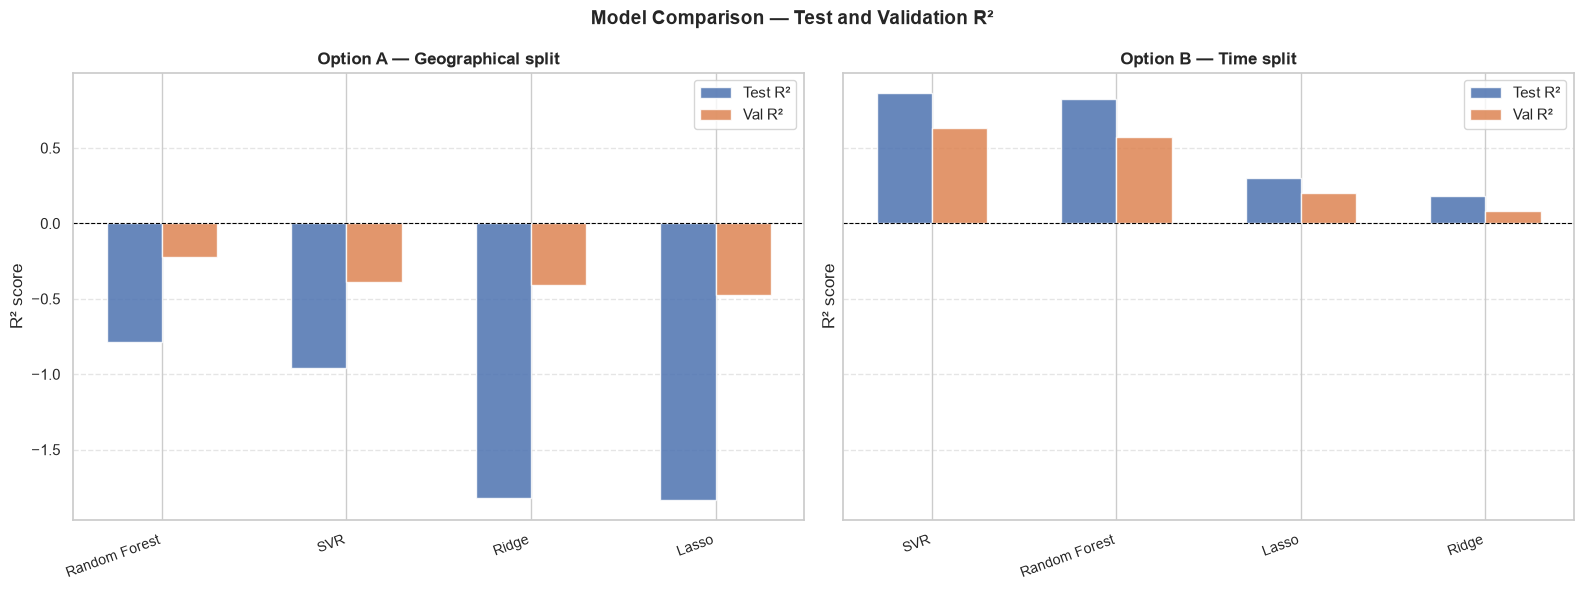

In [ ]:
# ==============================================================================
# R² comparison bar chart
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, test_tbl, val_tbl, label in zip(
    axes,
    [table_A_test, table_B_test],
    [table_A_val, table_B_val],
    ["Option A — Geographical split", "Option B — Time split"],
):
    x = np.arange(len(test_tbl))
    width = 0.3

    ax.bar(
        x - width / 2,
        test_tbl["R²"],
        width,
        label="Test R²",
        color="#4C72B0",
        alpha=0.85,
    )
    ax.bar(
        x + width / 2, val_tbl["R²"], width, label="Val R²", color="#DD8452", alpha=0.85
    )

    ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(test_tbl["Model"], rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("R² score")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    "Model Comparison — Test and Validation R²",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# Best hyperparameters summary
# ==============================================================================

print("Best hyperparameters selected by GridSearchCV")
print("=" * 60)

for approach_label, trained_dict in [("Option A", trained_A), ("Option B", trained_B)]:
    print(f"\n{approach_label}")
    print("-" * 40)
    for name, result in trained_dict.items():
        print(f"  {name:20s}: {result['best_params']}")

Best hyperparameters selected by GridSearchCV

Option A
----------------------------------------
  Ridge               : {'alpha': 1000}
  Lasso               : {'alpha': 1}
  SVR                 : {'C': 1, 'epsilon': 1.0, 'kernel': 'rbf'}
  Random Forest       : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}

Option B
----------------------------------------
  Ridge               : {'alpha': 1000}
  Lasso               : {'alpha': 1}
  SVR                 : {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
  Random Forest       : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


### Approach Deprecation and Model Improvement Strategy
 
#### Why Option A is Deprecated Going Forward
 
The results obtained in the previous section reveal a fundamental limitation
of the geographical split approach that is structural rather than
model-specific:
 
> **All four models produced negative R² scores on both the test and
> validation sets under Option A**, meaning every model performs worse than
> simply predicting the mean suicide rate of the training set.
 
This outcome is consistent across Ridge, Lasso, SVR and Random Forest,
which rules out any modelling explanation. The root cause is that **suicide
rates are shaped by deeply country-specific structural factors** — historical,
cultural, healthcare system quality — that are not fully transferable across
countries through the socioeconomic and mental health predictors available.
 
Option A is preserved in this notebook for transparency and methodological
completeness: it serves as empirical evidence that cross-country
generalisation is fundamentally limited in this domain, and represents a
valuable finding in itself. However, **all subsequent modelling and analysis
will be conducted exclusively under Option B** (time split), where the
results demonstrate genuine predictive power.
 
#### Motivation for the Improved Pipeline
 
The baseline Option B results showed that SVR and Random Forest explain
approximately 80% of temporal variance (R² ≈ 0.80), while Ridge and Lasso
underperform significantly (R² ≈ 0.18–0.30). Two targeted improvements
are introduced to address these limitations:
 
**1. Temporal feature engineering (lag and delta features)**
 
The baseline models treat each country-year as an independent observation.
However, suicide rates exhibit strong **temporal autocorrelation** — a
country's rate this year is highly predictive of its rate next year. By
adding lagged values and year-over-year changes as features, the models
gain access to the trajectory of key indicators rather than only their
instantaneous values. This is expected to benefit all models, but
particularly Ridge and Lasso which currently cannot capture non-linear
temporal dynamics.
 
**2. Expanded hyperparameter search**
 
Given the improved feature set, the same four models are retrained from
scratch on the enhanced dataset. All existing variables, trained models and
results from the baseline section are preserved unchanged — the improved
pipeline is fully independent.

### Feature Engineering — Temporal Features
 
#### Rationale
 
Each observation in the dataset represents a single country-year pair.
In the baseline, only the **level** of each indicator at time $t$ was used
to predict the suicide rate at time $t$. This ignores two important signals:
 
- **The previous level** (lag): where was this indicator last year? A country
  with high unemployment last year and high unemployment this year may behave
  differently from one that just experienced a sudden spike.
- **The direction of change** (delta): is the indicator improving or
  deteriorating? A rising unemployment rate signals economic stress even if
  the current level is moderate.
 
#### Feature Added
 
**Lag features** — value of the indicator in year $t-1$ for the same country:
 
$$x^{\text{lag}}_t = x_{t-1}$$
 
 
The following lag  features are added:
 
| Feature | Type | Rationale |
|---|---|---|
| `suicide_rate_lag1` | Lag | Strongest single predictor — autocorrelation in rates is very high |
| `gdp_lag1` | Lag | Economic conditions in the prior year influence current mental health outcomes with a delay |
| `unemployment_lag1` | Lag | Labour market stress has delayed effects on suicide risk |

 
#### Methodological Note on Data Leakage
 
Using $y_{t-1}$ (the previous year's suicide rate) as a feature for
predicting $y_t$ is **methodologically valid** because:
 
1. In a real forecasting scenario, last year's rate is already observed
   and published before the prediction is made.
2. The lag is computed before splitting, using the full development dataset,
   so that the lag value for 2016 correctly uses the known 2015 value.
3. No information from the *current* year's target leaks into the features.
 
The first year per country (2000) has no available lag and is dropped from
the enhanced dataset — a loss of 27 rows (~6% of training data), which is
acceptable.

In [ ]:
# ==============================================================================
# Feature engineering — lags only, no deltas
# ==============================================================================

df_enhanced = df_development.copy()
df_enhanced = df_enhanced.sort_values(["Country", "Year"]).reset_index(drop=True)

# Lag of the target — always included, used as the autoregressive baseline
df_enhanced["suicide_rate_lag1"] = df_enhanced.groupby("Country")["Suicide rate"].shift(1)

# Lag of EVERY current predictor — computed for all of them so the ablation
# study below can decide empirically which ones actually help, instead of
# picking GDP/unemployment by intuition.
for col in predictor_features:
    df_enhanced[f"{col}_lag1"] = df_enhanced.groupby("Country")[col].shift(1)

lag_cols_all = ["suicide_rate_lag1"] + [f"{c}_lag1" for c in predictor_features]

# Drop rows with no lag available (first year per country, 2000).
# Dropped on the FULL set of lag columns at once so every ablation config
# below trains/evaluates on exactly the same rows — otherwise RMSE/R²
# differences between configs could just reflect different sample sizes.
n_before = len(df_enhanced)
df_enhanced = df_enhanced.dropna(subset=lag_cols_all).reset_index(drop=True)
n_after = len(df_enhanced)

print(f"Rows dropped (first year per country, no lag available): {n_before - n_after}")
print(f"Enhanced dataset size: {n_after} rows")
print(f"\nLag features added: {len(lag_cols_all)}")
display(df_enhanced.head(3))

Rows dropped (first year per country, no lag available): 27
Enhanced dataset size: 567 rows

Lag features added: 19


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region,suicide_rate_lag1,Alcohol use disorders_lag1,Alzheimer's disease and other dementias_lag1,Anxiety disorders_lag1,Attention-deficit/hyperactivity disorder_lag1,Autism spectrum disorders_lag1,Bipolar disorder_lag1,Conduct disorder_lag1,Depressive disorders_lag1,Drug use disorders_lag1,Schizophrenia_lag1,GDP per capita_lag1,Unemployment rate (%)_lag1,Health expenditure (% GDP)_lag1,Population_lag1,Gini index_lag1,Urban population (%)_lag1,Internet users (% of population)_lag1,Physicians per 100000_lag1
0,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.18545,398.9,18.508048,Western Europe/Nordics,19.753390,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6
1,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.56000,406.0,19.413281,Western Europe/Nordics,18.508048,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9
2,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.70000,414.4,17.989560,Western Europe/Nordics,19.413281,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0


In [ ]:
# ==============================================================================
# Ablation study: does lagging GDP/unemployment (or everything) beat
# a model that only sees suicide_rate_lag1?
# ==============================================================================

# ==============================================================================
# Model instances and hyperparameter grids for the improved run
# New dicts — nothing from the baseline section is overwritten.
# ==============================================================================

models_v2 = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
}

param_grids_v2 = {
    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    },
    "Lasso": {
        "alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    },
    "SVR": {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.1, 0.5, 1.0],
        "kernel": ["linear", "rbf"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", 0.5],
    },
}

df_train_full = df_enhanced[df_enhanced["Year"].isin(train_years)].copy()
df_test_full  = df_enhanced[df_enhanced["Year"].isin(test_years)].copy()
df_val_full   = df_enhanced[df_enhanced["Year"].isin(val_years)].copy()

gdp_lag_col = "GDP per capita_lag1"
unemp_lag_col = "Unemployment rate (%)_lag1"

feature_sets = {
    "A - suicide lag only": predictor_features + ["suicide_rate_lag1"],
    "B - + gdp & unemployment lag": predictor_features + ["suicide_rate_lag1", gdp_lag_col, unemp_lag_col],
    "C - + all predictor lags": predictor_features + ["suicide_rate_lag1"] + [f"{c}_lag1" for c in predictor_features],
}

ablation_results = []

for config_name, feature_list in feature_sets.items():
    print(f"\n{'#'*70}\n# Config: {config_name}  ({len(feature_list)} features)\n{'#'*70}")

    X_train_c = df_train_full[feature_list].copy()
    X_test_c  = df_test_full[feature_list].copy()
    X_val_c   = df_val_full[feature_list].copy()
    y_train_c = df_train_full[TARGET].copy()
    y_test_c  = df_test_full[TARGET].copy()
    y_val_c   = df_val_full[TARGET].copy()

    scaler_c = RobustScaler()
    X_train_c_scaled = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=feature_list, index=X_train_c.index)
    X_test_c_scaled  = pd.DataFrame(scaler_c.transform(X_test_c),  columns=feature_list, index=X_test_c.index)
    X_val_c_scaled   = pd.DataFrame(scaler_c.transform(X_val_c),   columns=feature_list, index=X_val_c.index)

    cv_c = TimeSeriesSplit(n_splits=5)
    models_c = {
        "Ridge": Ridge(),
        "Lasso": Lasso(max_iter=10000),
        "SVR": SVR(),
        "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    }

    for name in models_c:
        trained = train_model(
            name=name, model=models_c[name], param_grid=param_grids_v2[name],
            X_train=X_train_c_scaled, y_train=y_train_c, cv=cv_c,
        )
        for split_label, X_split, y_split in [
            ("Test", X_test_c_scaled, y_test_c),
            ("Val", X_val_c_scaled, y_val_c),
        ]:
            ev = evaluate_model(trained, X_split, y_split, split_label)
            ev["config"] = config_name
            ev["n_features"] = len(feature_list)
            ablation_results.append(ev)

# --- Persistence baseline: ŷ(t) = suicide_rate_lag1, no model at all ---
for split_label, df_split in [("Test", df_test_full), ("Val", df_val_full)]:
    y_true = df_split[TARGET]
    y_pred = df_split["suicide_rate_lag1"]
    ablation_results.append({
        "model": "Persistence (y_t = y_t-1)",
        "config": "Baseline — no model",
        "split": split_label,
        "n_features": 1,
        "rmse": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "mae": round(mean_absolute_error(y_true, y_pred), 4),
        "r2": round(r2_score(y_true, y_pred), 4),
    })

ablation_df = pd.DataFrame(ablation_results)


######################################################################
# Config: A - suicide lag only  (19 features)
######################################################################

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 1}
  CV RMSE     : 2.4846
  Training time: 0.05s
  Ridge                | Test       — RMSE: 1.0287 | MAE: 0.7718 | R²: 0.9681
  Ridge                | Val        — RMSE: 0.9849 | MAE: 0.7425 | R²: 0.9562

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 0.1}
  CV RMSE     : 1.1693
  Training time: 0.05s
  Lasso                | Test       — RMSE: 1.0191 | MAE: 0.7835 | R²: 0.9687
  Lasso                | Val        — RMSE: 0.9602 | MAE: 0.7418 | R²: 0.9584

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 1, 'epsilon': 0.5, 'kernel': 'linear'}
  CV RMSE     : 2.3761
  Training time: 0.63s
  SVR                  | Test       — RMSE: 1.0333 | MAE: 0.7850

In [ ]:
summary = (
    ablation_df
    .pivot_table(index=["config", "model"], columns="split", values=["rmse", "r2"])
    .round(4)
)
display(summary.sort_index())

r2            rmse        
split                                                     Test     Val    Test     Val
config                       model                                                    
A - suicide lag only         Lasso                      0.9687  0.9584  1.0191  0.9602
                             Random Forest              0.9460  0.8661  1.3383  1.7218
                             Ridge                      0.9681  0.9562  1.0287  0.9849
                             SVR                        0.9678  0.9576  1.0333  0.9695
B - + gdp & unemployment lag Lasso                      0.9687  0.9584  1.0191  0.9602
                             Random Forest              0.9431  0.8658  1.3732  1.7238
                             Ridge                      0.9693  0.9571  1.0089  0.9742
                             SVR                        0.9690  0.9590  1.0138  0.9531
Baseline — no model          Persistence (y_t = y_t-1)  0.9644  0.9516  1.0864  1.0351
C - + all predictor lags     Lasso                      0.9687  0.9584  1.0191  0.9602
                             Random Forest              0.9356  0.8198  1.4606  1.9979
                             Ridge                      0.9657  0.9501  1.0653  1.0512
                             SVR                        0.9669  0.9543  1.0470  1.0061

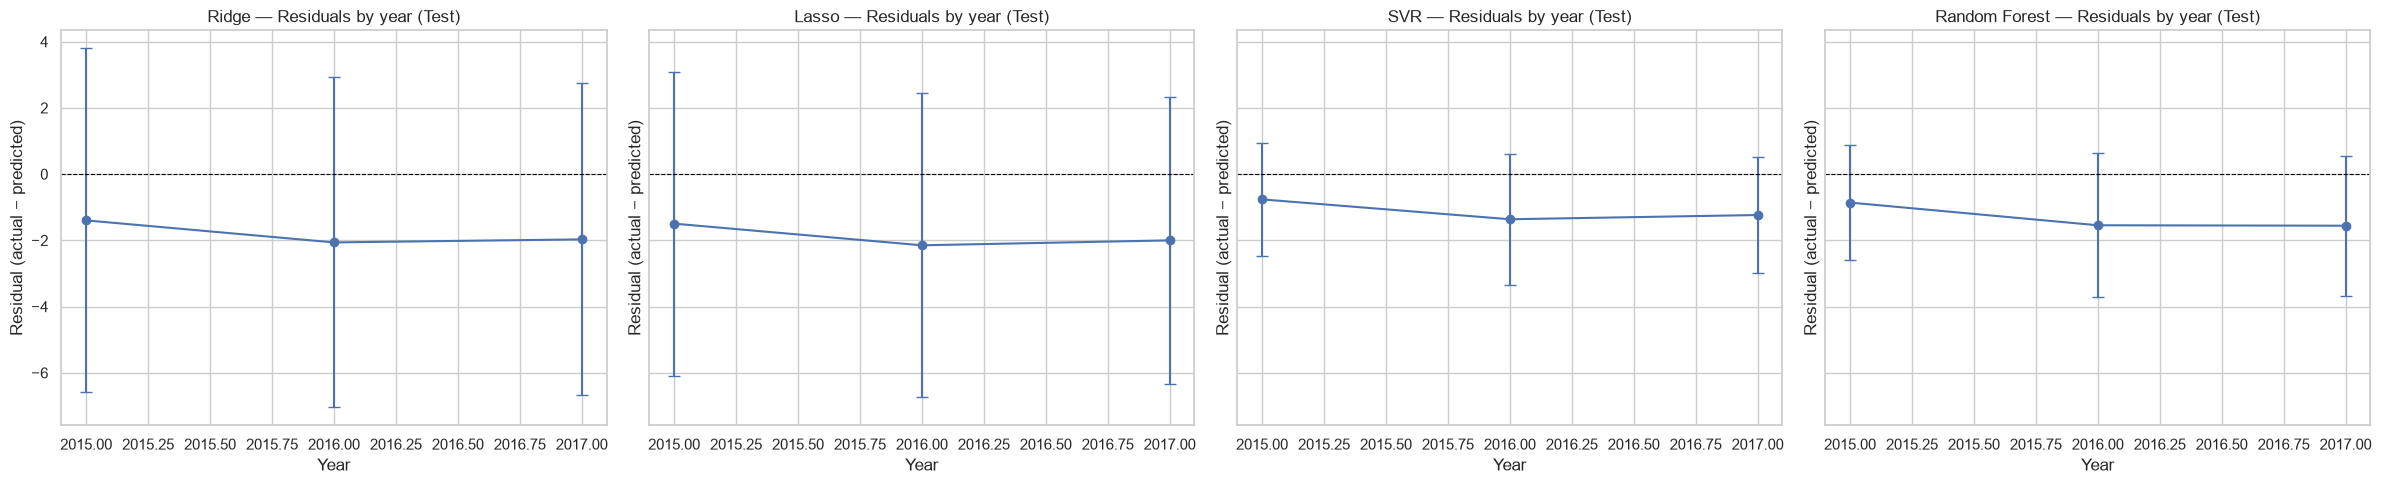

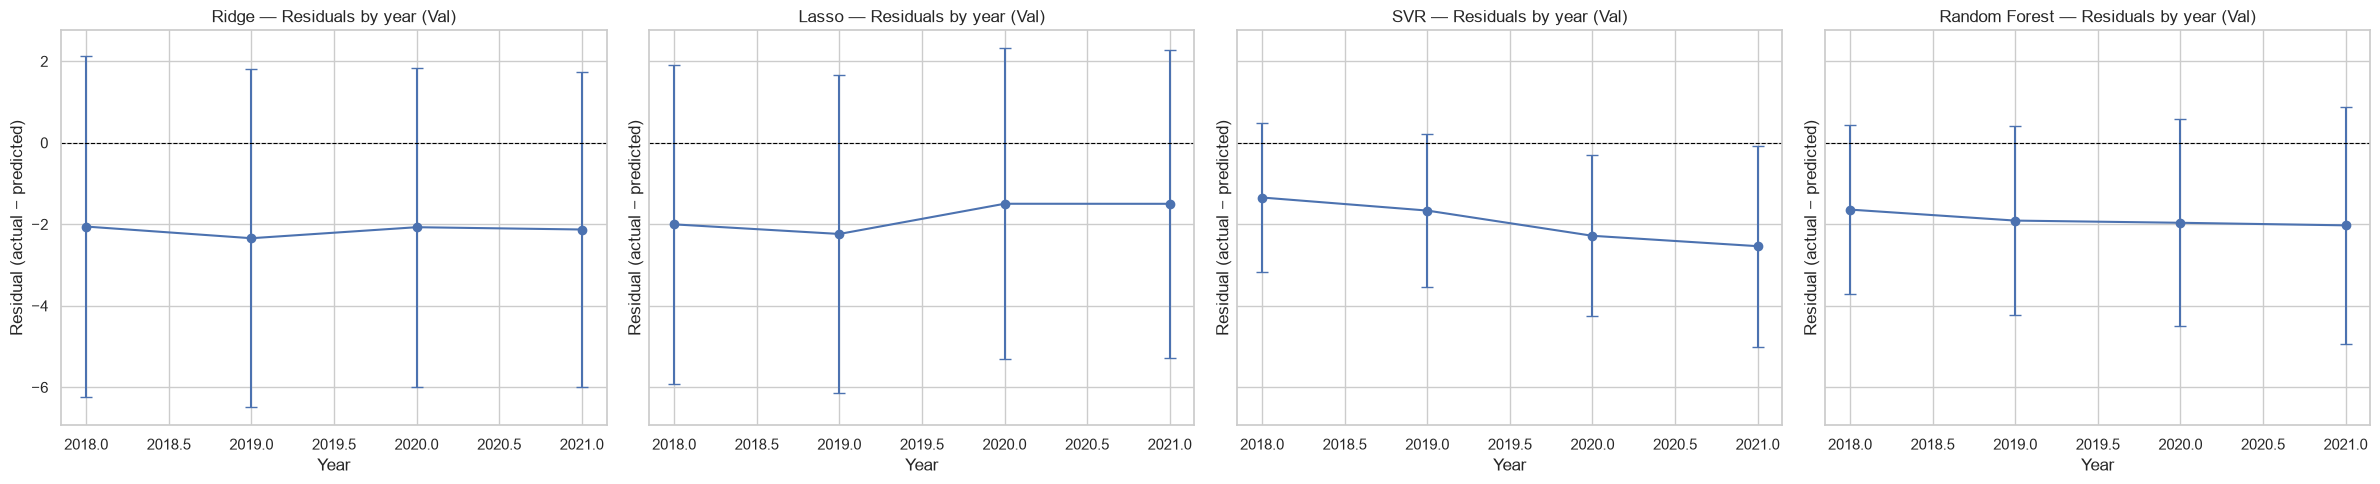

In [ ]:
def plot_residuals_by_year(trained_dict, df_split, X_split_scaled, y_split, split_label):
    fig, axes = plt.subplots(1, len(trained_dict), figsize=(6 * len(trained_dict), 5), sharey=True)
    if len(trained_dict) == 1:
        axes = [axes]

    for ax, (name, trained) in zip(axes, trained_dict.items()):
        model = trained["best_estimator"]
        y_pred = model.predict(X_split_scaled)
        residuals = y_split.values - y_pred

        resid_df = pd.DataFrame({"Year": df_split["Year"].values, "Residual": residuals})
        by_year = resid_df.groupby("Year")["Residual"]
        means = by_year.mean()
        stds = by_year.std()

        ax.errorbar(means.index, means.values, yerr=stds.values, fmt="o-", capsize=4, color="#4C72B0")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set_title(f"{name} — Residuals by year ({split_label})")
        ax.set_xlabel("Year")
        ax.set_ylabel("Residual (actual − predicted)")

    plt.tight_layout()
    plt.show()

# Test set (2016-2018) y Val set (2019-2021)
plot_residuals_by_year(trained_B, df_test_B, X_test_B_scaled, y_test_B, "Test")
plot_residuals_by_year(trained_B, df_val_B, X_val_B_scaled, y_val_B, "Val")

In [ ]:
print("Std de la tasa de suicidio real:")
print(f"  Test (2015-2017): {y_test_B.std():.4f}")
print(f"  Val  (2018-2021): {y_val_B.std():.4f}")

Std de la tasa de suicidio real:
  Test (2015-2017): 5.7922
  Val  (2018-2021): 4.7282


In [ ]:
def normalized_rmse_table(eval_list, y_test_std, y_val_std):
    """
    Adds NRMSE = RMSE / std(y) to each evaluation result, so RMSE becomes
    comparable across splits with different target variance.
    """
    rows = []
    for ev in eval_list:
        std_ref = y_test_std if ev["split"] == "Test" else y_val_std
        nrmse = round(ev["rmse"] / std_ref, 4)
        rows.append({
            "model": ev["model"],
            "split": ev["split"],
            "rmse": ev["rmse"],
            "nrmse": nrmse,
            "r2": ev["r2"],
        })
    return pd.DataFrame(rows)

y_test_std = y_test_B.std()
y_val_std = y_val_B.std()

nrmse_df = normalized_rmse_table(eval_B, y_test_std, y_val_std)
display(nrmse_df.sort_values(["model", "split"]))

,model,split,rmse,nrmse,r2
2,Lasso,Test,4.8137,0.8311,0.3007
3,Lasso,Val,4.2053,0.8894,0.2015
6,Random Forest,Test,2.4022,0.4147,0.8259
7,Random Forest,Val,3.0774,0.6509,0.5724
0,Ridge,Test,5.2058,0.8988,0.1821
1,Ridge,Val,4.5030,0.9524,0.0845
4,SVR,Test,2.1226,0.3665,0.8640
5,SVR,Val,2.8483,0.6024,0.6337


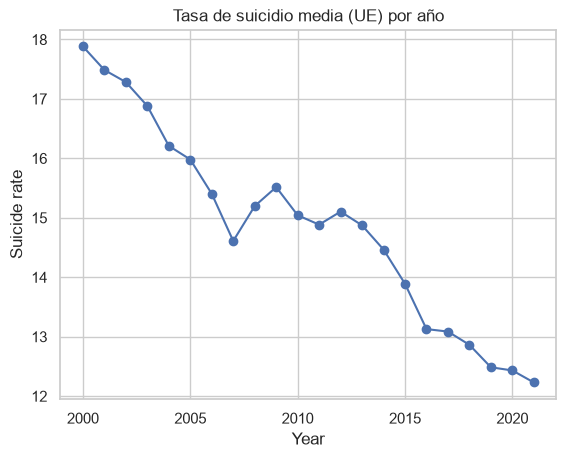

In [ ]:
df_development.groupby("Year")["Suicide rate"].mean().plot(marker="o")
plt.title("Tasa de suicidio media (UE) por año")
plt.ylabel("Suicide rate")
plt.show()

In [ ]:
# ==============================================================================
# Boosted models (XGBoost, CatBoost) + opción de incluir tendencia temporal (Year)
# Se añade a trained_B / eval_B, así toda la infraestructura de tablas
# (build_results_table, normalized_rmse_table) sigue funcionando sin cambios.
# ==============================================================================

!pip install catboost --quiet

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

USE_YEAR_TREND = True  # cambia a True para repetir todo con Year incluido
predictor_features_trend = predictor_features + ["Year"]

features_run = predictor_features_trend if USE_YEAR_TREND else predictor_features
run_label = "with Year" if USE_YEAR_TREND else "no Year"

# --- Re-split y re-escalado con el set de features elegido ---
X_train_run = df_train_B[features_run].copy()
X_test_run  = df_test_B[features_run].copy()
X_val_run   = df_val_B[features_run].copy()

scaler_run = RobustScaler()
X_train_run_scaled = pd.DataFrame(scaler_run.fit_transform(X_train_run), columns=features_run, index=X_train_run.index)
X_test_run_scaled  = pd.DataFrame(scaler_run.transform(X_test_run),  columns=features_run, index=X_test_run.index)
X_val_run_scaled   = pd.DataFrame(scaler_run.transform(X_val_run),   columns=features_run, index=X_val_run.index)

models_boost = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1, objective="reg:squarederror"),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0),
}

param_grids_boost = {
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0],
    },
    "CatBoost": {
        "iterations": [200, 400],
        "depth": [3, 4, 5],
        "learning_rate": [0.05, 0.1],
        "l2_leaf_reg": [3, 7],
    },
}

cv_B_boost = TimeSeriesSplit(n_splits=5)

trained_boost = {}
print(f"BOOSTED MODELS — TRAINING ({run_label})")
for name in models_boost:
    trained_boost[name] = train_model(
        name=name, model=models_boost[name], param_grid=param_grids_boost[name],
        X_train=X_train_run_scaled, y_train=y_train_B, cv=cv_B_boost,
    )

eval_boost = []
print("\nBOOSTED MODELS — EVALUATION")
for name in trained_boost:
    eval_boost.append(evaluate_model(trained_boost[name], X_test_run_scaled, y_test_B, "Test"))
    eval_boost.append(evaluate_model(trained_boost[name], X_val_run_scaled, y_val_B, "Val"))

# --- Fusiona con los modelos ya entrenados y muestra la tabla con NRMSE ---
all_eval = eval_B + eval_boost
all_trained = {**trained_B, **trained_boost}

final_table = normalized_rmse_table(all_eval, y_test_std, y_val_std)
final_table["features"] = run_label
display(final_table.sort_values(["split", "nrmse"]))

BOOSTED MODELS — TRAINING (with Year)

  Training: XGBoost
  Grid size: 5 params | Combinations: 48
  Best params : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
  CV RMSE     : 6.7056
  Training time: 2.9s

  Training: CatBoost
  Grid size: 4 params | Combinations: 24
  Best params : {'depth': 4, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
  CV RMSE     : 6.9194
  Training time: 24.15s

BOOSTED MODELS — EVALUATION
  XGBoost              | Test       — RMSE: 3.2295 | MAE: 2.4086 | R²: 0.6852
  XGBoost              | Val        — RMSE: 4.9865 | MAE: 3.6816 | R²: -0.1227
  CatBoost             | Test       — RMSE: 2.1903 | MAE: 1.7206 | R²: 0.8552
  CatBoost             | Val        — RMSE: 3.2088 | MAE: 2.4856 | R²: 0.5351


,model,split,rmse,nrmse,r2,features
4,SVR,Test,2.1226,0.3665,0.8640,with Year
10,CatBoost,Test,2.1903,0.3781,0.8552,with Year
6,Random Forest,Test,2.4022,0.4147,0.8259,with Year
8,XGBoost,Test,3.2295,0.5576,0.6852,with Year
2,Lasso,Test,4.8137,0.8311,0.3007,with Year
0,Ridge,Test,5.2058,0.8988,0.1821,with Year
5,SVR,Val,2.8483,0.6024,0.6337,with Year
7,Random Forest,Val,3.0774,0.6509,0.5724,with Year
11,CatBoost,Val,3.2088,0.6787,0.5351,with Year
3,Lasso,Val,4.2053,0.8894,0.2015,with Year


# DEPRECATED

In [ ]:
# ==============================================================================
# Feature list and scaling for the enhanced dataset
# ==============================================================================

# Updated feature list — all original features plus the six new temporal ones
predictor_features_v2 = [c for c in df_enhanced.columns if c not in ID_COLS + [TARGET]]

print(f"\nTotal features (enhanced): {len(predictor_features_v2)}")
print(f"New temporal features:")
print([f for f in predictor_features_v2 if f not in predictor_features])

# Fit scaler ONLY on training data — transform test and val
scaler_B2 = RobustScaler()

X_train_B2 = df_train_B2[predictor_features_v2].copy()
X_test_B2 = df_test_B2[predictor_features_v2].copy()
X_val_B2 = df_val_B2[predictor_features_v2].copy()

y_train_B2 = df_train_B2[TARGET].copy()
y_test_B2 = df_test_B2[TARGET].copy()
y_val_B2 = df_val_B2[TARGET].copy()

X_train_B2_scaled = pd.DataFrame(
    scaler_B2.fit_transform(X_train_B2),
    columns=predictor_features_v2,
    index=X_train_B2.index,
)
X_test_B2_scaled = pd.DataFrame(
    scaler_B2.transform(X_test_B2),
    columns=predictor_features_v2,
    index=X_test_B2.index,
)
X_val_B2_scaled = pd.DataFrame(
    scaler_B2.transform(X_val_B2),
    columns=predictor_features_v2,
    index=X_val_B2.index,
)

print("\nEnhanced Option B — scaled shapes:")
print(f"  X_train_B2: {X_train_B2_scaled.shape} | y_train_B2: {y_train_B2.shape}")
print(f"  X_test_B2:  {X_test_B2_scaled.shape}  | y_test_B2:  {y_test_B2.shape}")
print(f"  X_val_B2:   {X_val_B2_scaled.shape}   | y_val_B2:   {y_val_B2.shape}")

# Sanity check — median ~0, IQR ~1 on train
print("\nScaling sanity check (train B2) — median ~0, IQR ~1:")
sanity_B2 = pd.DataFrame(
    {
        "Median": X_train_B2_scaled.median().round(3),
        "IQR": (
            X_train_B2_scaled.quantile(0.75) - X_train_B2_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_B2)


Total features (enhanced): 37
New temporal features:
['suicide_rate_lag1', 'Alcohol use disorders_lag1', "Alzheimer's disease and other dementias_lag1", 'Anxiety disorders_lag1', 'Attention-deficit/hyperactivity disorder_lag1', 'Autism spectrum disorders_lag1', 'Bipolar disorder_lag1', 'Conduct disorder_lag1', 'Depressive disorders_lag1', 'Drug use disorders_lag1', 'Schizophrenia_lag1', 'GDP per capita_lag1', 'Unemployment rate (%)_lag1', 'Health expenditure (% GDP)_lag1', 'Population_lag1', 'Gini index_lag1', 'Urban population (%)_lag1', 'Internet users (% of population)_lag1', 'Physicians per 100000_lag1']


NameError: name 'df_train_B2' is not defined

### Improved Option B — Training with Temporal Features
 
All four models are retrained from scratch on the enhanced dataset
(`X_train_B2_scaled`, `y_train_B2`) using `TimeSeriesSplit(n_splits=5)`
as before, keeping the temporal integrity of the cross-validation folds.
 
The `train_model` and `evaluate_model` functions defined in the baseline
section are reused unchanged — their design as stateless functions that
accept any dataset means they work directly with the new splits without
modification.
 
New variable names (`trained_B2`, `eval_B2`) ensure the baseline results
(`trained_B`, `eval_B`) remain fully intact and available for comparison.

In [ ]:
# ==============================================================================
# Model instances and hyperparameter grids for the improved run
# New dicts — nothing from the baseline section is overwritten.
# ==============================================================================

models_v2 = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=10000),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
}

param_grids_v2 = {
    "Ridge": {
        "alpha": [0.01, 0.1, 1, 10, 100, 1000],
    },
    "Lasso": {
        "alpha": [0.001, 0.01, 0.1, 1, 10, 100],
    },
    "SVR": {
        "C": [0.1, 1, 10, 100],
        "epsilon": [0.1, 0.5, 1.0],
        "kernel": ["linear", "rbf"],
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", 0.5],
    },
}

In [ ]:
# ==============================================================================
# Train all models on the enhanced Option B dataset
# ==============================================================================

cv_B2 = TimeSeriesSplit(n_splits=5)

trained_B2 = {}

print("IMPROVED OPTION B — TRAINING (with temporal features)")
for name in models_v2:
    trained_B2[name] = train_model(
        name=name,
        model=models_v2[name],
        param_grid=param_grids_v2[name],
        X_train=X_train_B2_scaled,
        y_train=y_train_B2,
        cv=cv_B2,
    )

IMPROVED OPTION B — TRAINING (with temporal features)

  Training: Ridge
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 0.01}
  CV RMSE     : 0.1747
  Training time: 9.71s

  Training: Lasso
  Grid size: 1 params | Combinations: 6
  Best params : {'alpha': 0.001}
  CV RMSE     : 0.0024
  Training time: 0.05s

  Training: SVR
  Grid size: 3 params | Combinations: 24
  Best params : {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
  CV RMSE     : 0.8141
  Training time: 0.17s

  Training: Random Forest
  Grid size: 4 params | Combinations: 72
  Best params : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 200}
  CV RMSE     : 3.7959
  Training time: 59.21s


In [ ]:
# ==============================================================================
# Evaluate all models on test and validation sets
# ==============================================================================

eval_B2 = []

print("\nIMPROVED OPTION B — EVALUATION")
print("=" * 60)

for name in trained_B2:
    eval_B2.append(
        evaluate_model(trained_B2[name], X_test_B2_scaled, y_test_B2, "Test")
    )
    eval_B2.append(evaluate_model(trained_B2[name], X_val_B2_scaled, y_val_B2, "Val"))


IMPROVED OPTION B — EVALUATION
  Ridge                | Test       — RMSE: 0.0004 | MAE: 0.0003 | R²: 1.0000
  Ridge                | Val        — RMSE: 0.0004 | MAE: 0.0003 | R²: 1.0000
  Lasso                | Test       — RMSE: 0.0015 | MAE: 0.0012 | R²: 1.0000
  Lasso                | Val        — RMSE: 0.0013 | MAE: 0.0010 | R²: 1.0000
  SVR                  | Test       — RMSE: 0.0683 | MAE: 0.0595 | R²: 0.9999
  SVR                  | Val        — RMSE: 0.0738 | MAE: 0.0622 | R²: 0.9998
  Random Forest        | Test       — RMSE: 1.3590 | MAE: 0.9825 | R²: 0.9443
  Random Forest        | Val        — RMSE: 1.7861 | MAE: 1.2176 | R²: 0.8560


In [ ]:
# ==============================================================================
# Results tables for improved Option B
# ==============================================================================

table_B2_test = build_results_table(eval_B2, trained_B2, "Test", "Improved Option B")
table_B2_val = build_results_table(eval_B2, trained_B2, "Val", "Improved Option B")


Improved Option B — Test set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,Ridge,0.1747,0.0004,0.0003,1.0000,9.71
1,Lasso,0.0024,0.0015,0.0012,1.0000,0.05
2,SVR,0.8141,0.0683,0.0595,0.9999,0.17
3,Random Forest,3.7959,1.3590,0.9825,0.9443,59.21



Improved Option B — Val set results:


,Model,CV RMSE,RMSE,MAE,R²,Time (s)
0,Ridge,0.1747,0.0004,0.0003,1.0000,9.71
1,Lasso,0.0024,0.0013,0.0010,1.0000,0.05
2,SVR,0.8141,0.0738,0.0622,0.9998,0.17
3,Random Forest,3.7959,1.7861,1.2176,0.8560,59.21


### Baseline vs Improved: Option B Comparison
 
The following charts directly compare the baseline Option B models (trained
without temporal features) against the improved pipeline (with lag and delta
features), allowing the contribution of feature engineering to be quantified
independently of model choice.
 
**Solid bars** represent the baseline results. **Hatched bars** represent the
improved results. The same colour scheme is used for test (blue) and
validation (orange) splits across both versions.
 
A reduction in RMSE and an increase in R² in the improved version confirm
that the temporal features carry genuine predictive signal beyond the
instantaneous feature levels used in the baseline.

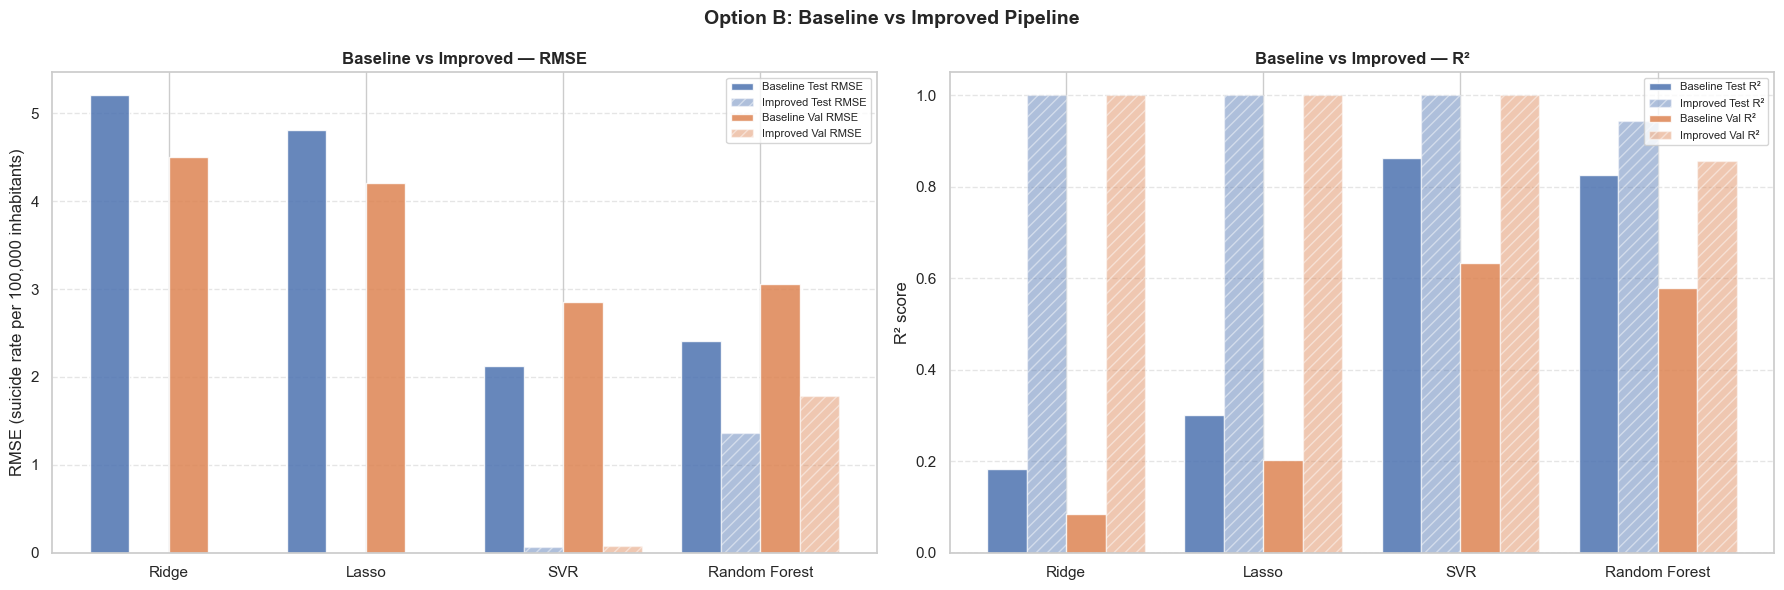

In [ ]:
# ==============================================================================
# Side-by-side RMSE and R² comparison: baseline vs improved
# ==============================================================================

common_models = ["Ridge", "Lasso", "SVR", "Random Forest"]

# Extract metrics for all common models from both runs
baseline_test_rmse = [
    next(r["rmse"] for r in eval_B if r["model"] == m and r["split"] == "Test")
    for m in common_models
]
baseline_val_rmse = [
    next(r["rmse"] for r in eval_B if r["model"] == m and r["split"] == "Val")
    for m in common_models
]
improved_test_rmse = [
    next(r["rmse"] for r in eval_B2 if r["model"] == m and r["split"] == "Test")
    for m in common_models
]
improved_val_rmse = [
    next(r["rmse"] for r in eval_B2 if r["model"] == m and r["split"] == "Val")
    for m in common_models
]
baseline_test_r2 = [
    next(r["r2"] for r in eval_B if r["model"] == m and r["split"] == "Test")
    for m in common_models
]
baseline_val_r2 = [
    next(r["r2"] for r in eval_B if r["model"] == m and r["split"] == "Val")
    for m in common_models
]
improved_test_r2 = [
    next(r["r2"] for r in eval_B2 if r["model"] == m and r["split"] == "Test")
    for m in common_models
]
improved_val_r2 = [
    next(r["r2"] for r in eval_B2 if r["model"] == m and r["split"] == "Val")
    for m in common_models
]

x = np.arange(len(common_models))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- RMSE comparison ---
ax = axes[0]
ax.bar(
    x - 1.5 * width,
    baseline_test_rmse,
    width,
    label="Baseline Test RMSE",
    color="#4C72B0",
    alpha=0.85,
)
ax.bar(
    x - 0.5 * width,
    improved_test_rmse,
    width,
    label="Improved Test RMSE",
    color="#4C72B0",
    alpha=0.45,
    hatch="///",
)
ax.bar(
    x + 0.5 * width,
    baseline_val_rmse,
    width,
    label="Baseline Val RMSE",
    color="#DD8452",
    alpha=0.85,
)
ax.bar(
    x + 1.5 * width,
    improved_val_rmse,
    width,
    label="Improved Val RMSE",
    color="#DD8452",
    alpha=0.45,
    hatch="///",
)
ax.set_xticks(x)
ax.set_xticklabels(common_models, fontsize=11)
ax.set_ylabel("RMSE (suicide rate per 100,000 inhabitants)")
ax.set_title("Baseline vs Improved — RMSE", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# --- R² comparison ---
ax = axes[1]
ax.bar(
    x - 1.5 * width,
    baseline_test_r2,
    width,
    label="Baseline Test R²",
    color="#4C72B0",
    alpha=0.85,
)
ax.bar(
    x - 0.5 * width,
    improved_test_r2,
    width,
    label="Improved Test R²",
    color="#4C72B0",
    alpha=0.45,
    hatch="///",
)
ax.bar(
    x + 0.5 * width,
    baseline_val_r2,
    width,
    label="Baseline Val R²",
    color="#DD8452",
    alpha=0.85,
)
ax.bar(
    x + 1.5 * width,
    improved_val_r2,
    width,
    label="Improved Val R²",
    color="#DD8452",
    alpha=0.45,
    hatch="///",
)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(common_models, fontsize=11)
ax.set_ylabel("R² score")
ax.set_title("Baseline vs Improved — R²", fontsize=12, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    "Option B: Baseline vs Improved Pipeline",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

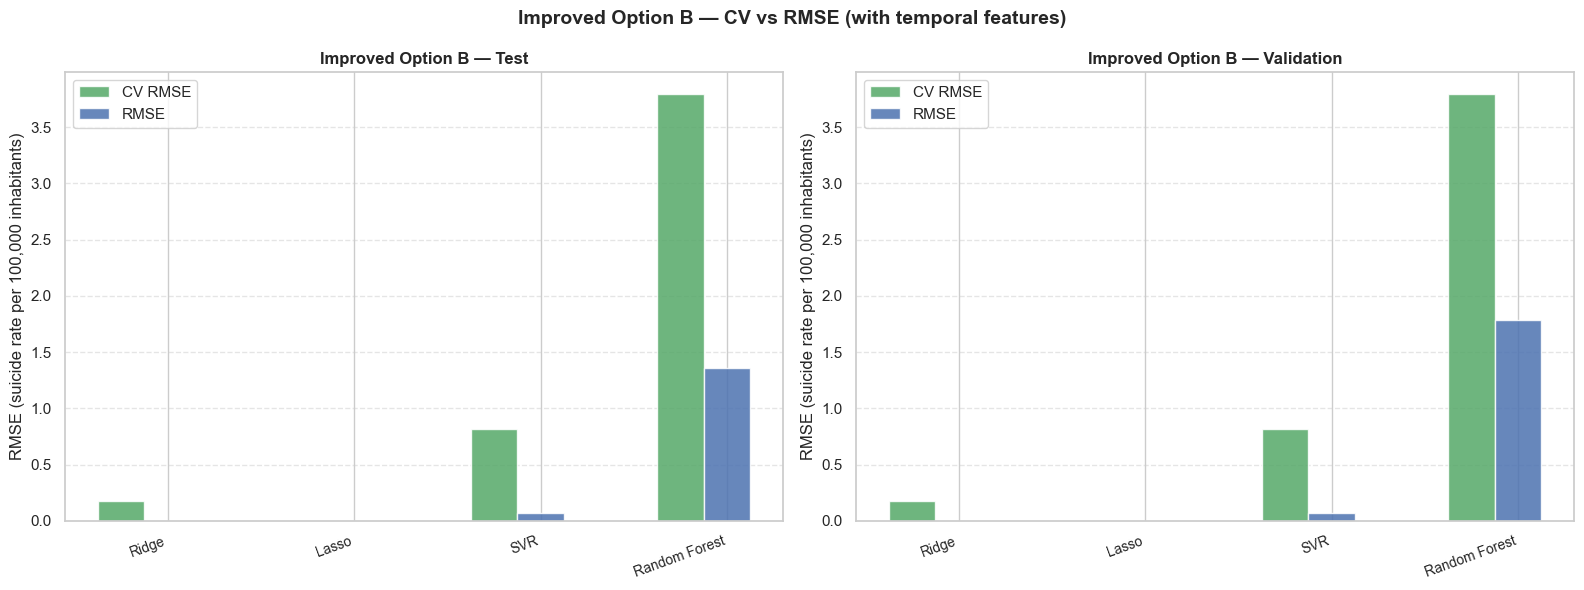

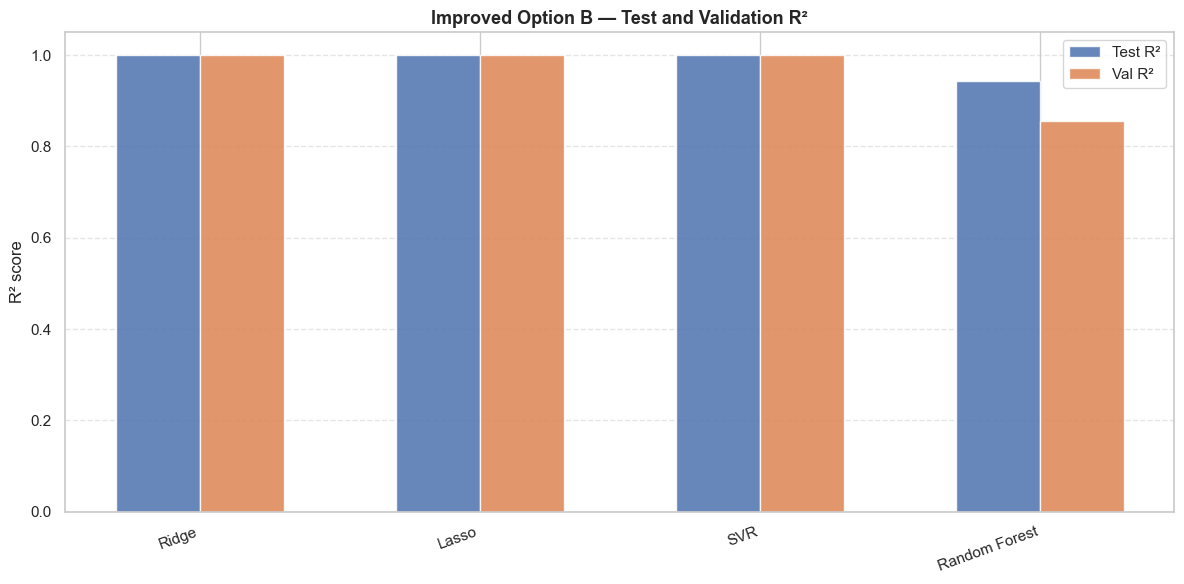

In [ ]:
# ==============================================================================
# Full improved results charts (RMSE and R²)
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, tbl, label in zip(
    axes,
    [table_B2_test, table_B2_val],
    ["Improved Option B — Test", "Improved Option B — Validation"],
):
    x = np.arange(len(tbl))
    width = 0.25
    ax.bar(
        x - width, tbl["CV RMSE"], width, label="CV RMSE", color="#55A868", alpha=0.85
    )
    ax.bar(x, tbl["RMSE"], width, label="RMSE", color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(tbl["Model"], rotation=20, ha="right", fontsize=10)
    ax.set_ylabel("RMSE (suicide rate per 100,000 inhabitants)")
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.suptitle(
    "Improved Option B — CV vs RMSE (with temporal features)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(table_B2_test))
width = 0.3
ax.bar(
    x - width / 2,
    table_B2_test["R²"],
    width,
    label="Test R²",
    color="#4C72B0",
    alpha=0.85,
)
ax.bar(
    x + width / 2,
    table_B2_val["R²"],
    width,
    label="Val R²",
    color="#DD8452",
    alpha=0.85,
)
ax.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(table_B2_test["Model"], rotation=20, ha="right", fontsize=11)
ax.set_ylabel("R² score")
ax.set_title(
    "Improved Option B — Test and Validation R²",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# Best hyperparameters for improved models
# ==============================================================================

print("Best hyperparameters — Improved Option B")
print("=" * 60)
for name, result in trained_B2.items():
    print(f"  {name:22s}: {result['best_params']}")

Best hyperparameters — Improved Option B
  Ridge                 : {'alpha': 0.01}
  Lasso                 : {'alpha': 0.001}
  SVR                   : {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
  Random Forest         : {'max_depth': None, 'max_features': 0.5, 'min_samples_split': 10, 'n_estimators': 200}
